In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import uproot
# import pandas as pd
# import awkward as ak
import re
from datetime import datetime, timedelta
import os

# this doesnt seem necessary and i cant find it anyways
#from tqdm.notebook import tqdm

from matplotlib.colors import LogNorm
import time

In [3]:
def baseline_subtract(trace):
    baseline = np.mean(trace[-100:])
    trace = trace.astype(float)
    trace -= baseline
    return trace

def delay_correct(trace, boardID):
    if (boardID<1) or (boardID>4):
        print("Bad BoardID")
        return False
    elif boardID!=1:
        return trace[24*(4-boardID):-24*(boardID-1)]
    else:
        return trace[24*3:]
    
def integrate_ROI_whole(trace):
    factor = 2000/(2**14 - 1)
    return -1*np.sum(trace)*factor*2/50

def integrate_ROI_majority(trace):
    factor = 2000/(2**14 - 1)
    return -1*np.sum(trace[160:230])*factor*2/50

def integrate_ROI_alpha(trace):
    factor = 2000/(2**14 - 1)
    return -1*np.sum(trace[320:390])*factor*2/50

def integrate_ROI_tp(trace):
    factor = 2000/(2**14 - 1)
    return -1*np.sum(trace[380:450])*factor*2/50

def integrate_ROI_v1740(trace):
    factor = 2000/(2**12 - 1)
    #return -1*np.sum(trace[340:370])*factor*2/50
    #return -1*np.sum(trace[350:450])*factor*2/50
    return -1*np.sum(trace)*factor*2/50

def get_calib(filename):
    df = pd.read_csv(filename)
    if len(df) != 58:
        print('Not all channels in calibration file!')
        #return None
    return df.set_index('ch_name')['spe_mean'].to_dict()

def get_height(trace):
    factor = 2000/(2**14 - 1)
    #return -1*np.min(trace[150:250])*factor
    return -1*np.min(trace[210:280])*factor

def get_height_alpha(trace):
    factor = 2000/(2**14 - 1)
    return -1*np.min(trace[90:120])*factor

def gaussian(x, mu, sigma, amplitude):
    return amplitude * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fit(data, bins=100, range=(-10, 1000), window_size=10):
    # Step 1: Generate the histogram (frequency counts and bin edges)
    counts, bin_edges = np.histogram(data, bins=bins, range=range)
    
    # Step 2: Calculate bin centers (midpoints of each bin)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Step 3: Identify the peak bin (where counts are maximum)
    peak_index = np.argmax(counts)
    median = np.median(data)
    #peak_index = np.argmin(np.abs(bin_centers - median))
    peak_center = bin_centers[peak_index]
    
    # Step 4: Define the region around the peak to fit
    # Use a window size around the peak (e.g., 5 bins to the left and right)
    start_index = max(0, peak_index - window_size)
    end_index = min(len(bin_centers), peak_index + window_size)
    
    # Step 5: Fit the Gaussian to the selected region
    # Use the selected bin centers and counts around the peak
    selected_bin_centers = bin_centers[start_index:end_index]
    selected_counts = counts[start_index:end_index]
    
    # Initial guess for the parameters: mean (mu), standard deviation (sigma), and amplitude
    initial_guess = [peak_center, np.std(data), max(selected_counts)]
    
    # Fit the Gaussian to the selected region
    popt, _ = opt.curve_fit(gaussian, selected_bin_centers, selected_counts, p0=initial_guess, maxfev=10000)

    # Extract the parameters of the fitted Gaussian
    mu, sigma, amplitude = popt
    '''
    #Step 6: Plotting the histogram and the fitted Gaussian curve
    plt.hist(data, bins=bins, range=range, histtype='step', color='g', label='Histogram')
    
    # Generate a smooth range of x values for plotting the Gaussian
    plt.plot(selected_bin_centers, gaussian(selected_bin_centers, mu, sigma, amplitude), color='r', label='Fitted Gaussian')
    
    # Add labels and legend to the plot
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    
    # Show the plot
    plt.show()
    '''
    # Return histogram data and fitted Gaussian parameters (mu, sigma, amplitude)
    return mu, sigma, amplitude

def get_pe(traces, majority_ev, spe_means, event_ttt):
    tot_pe = np.zeros(len(traces['adc_b1_ch1']))
    side_pe = np.zeros(len(traces['adc_b1_ch1']))
    bot_pe = np.zeros(len(traces['adc_b1_ch1']))
    row1_pe = np.zeros(len(traces['adc_b1_ch1']))
    row2_pe = np.zeros(len(traces['adc_b1_ch1']))
    row3_pe = np.zeros(len(traces['adc_b1_ch1']))
    row4_pe = np.zeros(len(traces['adc_b1_ch1']))
    row5_pe = np.zeros(len(traces['adc_b1_ch1']))
    row6_pe = np.zeros(len(traces['adc_b1_ch1']))
    row7_pe = np.zeros(len(traces['adc_b1_ch1']))
    times = np.zeros(len(traces['adc_b1_ch1']))

    bad_chs = ['adc_b1_ch0', 'adc_b2_ch15', 'adc_b4_ch15', 'adc_b4_ch12', 'adc_b4_ch13', 'adc_b4_ch14', 'adc_b3_ch3', 'adc_b3_ch7']
    pattern1 = r'b(\d+)_ch(\d+)'
    pattern2 = r'b(\d+)_p(\d+)'
    for key in traces.keys():
        boardID = re.search(pattern1, key).group(1)
        boardID = int(boardID)
        if (boardID>4) or (key in bad_chs):
            continue
        chkey = chmap[key]
        for ev, trace in enumerate(traces[key]):
            if ev in majority_ev:
                if chkey=='bt_p1':
                    times[ev] += event_ttt[ev]*8e-9
                trace_sub = baseline_subtract(trace)
                trace_good = delay_correct(trace_sub, boardID)
                pulse = integrate_ROI_majority(trace_good)
                pulse_pe = pulse/spe_means[key]
                tot_pe[ev] += pulse_pe
                if ('bt' in chkey):
                    bot_pe[ev] += pulse_pe
                else:
                    side_pe[ev] += pulse_pe
                    column = re.search(pattern2, chkey).group(1)
                    row = re.search(pattern2, chkey).group(2)
                    column = int(column)
                    row = int(row)
                    if column<5:
                        if row==1:
                            row1_pe[ev] += pulse_pe
                        elif row==2:
                            row2_pe[ev] += pulse_pe
                        elif row==3:
                            row3_pe[ev] += pulse_pe
                        else:
                            row4_pe[ev] += pulse_pe
                    else:
                        if row==1:
                            row5_pe[ev] += pulse_pe
                        elif row==2:
                            row6_pe[ev] += pulse_pe
                        else:
                            row7_pe[ev] += pulse_pe
                      
    pes = {}
    pes['bottom'] = bot_pe
    pes['total'] = tot_pe
    pes['side'] = side_pe
    pes['row1'] = row1_pe
    pes['row2'] = row2_pe
    pes['row3'] = row3_pe 
    pes['row4'] = row4_pe
    pes['row5'] = row5_pe
    pes['row6'] = row6_pe
    pes['row7'] = row7_pe
    pes['times'] = times
    return pes

def get_majority(traces):
    trigtag_tpch = 'adc_b5_ch33'
    trigtag_alphach = 'adc_b5_ch34'
    trigtag_majoritych = 'adc_b5_ch35'
    trigtags = [trigtag_tpch, trigtag_alphach, trigtag_majoritych]

    tp_ev = []
    alpha_ev = []
    majority_ev = []

    for key in traces.keys():
        if key in trigtags:
            for ev, trace in enumerate(traces[key]):
                if np.min(trace) < 3000:
                    if key==trigtag_tpch:
                        tp_ev.append(ev)
                    elif key==trigtag_alphach:
                        alpha_ev.append(ev)
                    else:
                        majority_ev.append(ev)

    majority_ev = [ev for ev in majority_ev if ev not in tp_ev]
    alpha_ev = [ev for ev in alpha_ev if (ev not in tp_ev) and (ev not in majority_ev)]
    
    return majority_ev

def get_traces(fname):
    f = uproot.open(fname)
    daq = f['daq']
    traces = {}
    for key in daq.keys():
        if 'adc' in key:
            traces[key] = daq[key].array(library='np')
    event_ttt1 = daq['event_ttt_1'].array(library='np')
    event_ttt2 = daq['event_ttt_2'].array(library='np')
    event_ttt3 = daq['event_ttt_3'].array(library='np')
    event_ttt4 = daq['event_ttt_4'].array(library='np')
    event_id = daq['event_id'].array(library='np')
    #event_ttt = daq['event_ttt'].array(library='np')
    
    return traces, event_ttt1.astype(np.int64), event_ttt2.astype(np.int64), event_ttt3.astype(np.int64), event_ttt4.astype(np.int64), event_id

def get_1t_traces(fname):
    f = uproot.open(fname)
    daq = f['daq']
    traces = {}
    for key in daq.keys():
        if 'adc' in key:
            traces[key] = daq[key].array(library='np')
    event_ttt1 = daq['event_ttt_1'].array(library='np')
    event_ttt2 = daq['event_ttt_2'].array(library='np')
    event_ttt3 = daq['event_ttt_3'].array(library='np')
    event_ttt4 = daq['event_ttt_4'].array(library='np')
    event_ttt5 = daq['event_ttt_5'].array(library='np')
    event_id = daq['event_id'].array(library='np')
    event_sanity = daq['event_sanity'].array(library='np')
    #event_ttt = daq['event_ttt'].array(library='np')
    
    return traces, event_ttt1.astype(np.int64), event_ttt2.astype(np.int64), event_ttt3.astype(np.int64), event_ttt4.astype(np.int64), event_ttt5.astype(np.int64), event_id, event_sanity

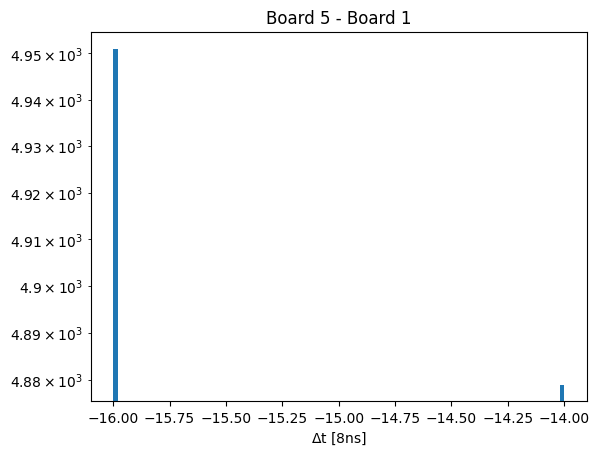

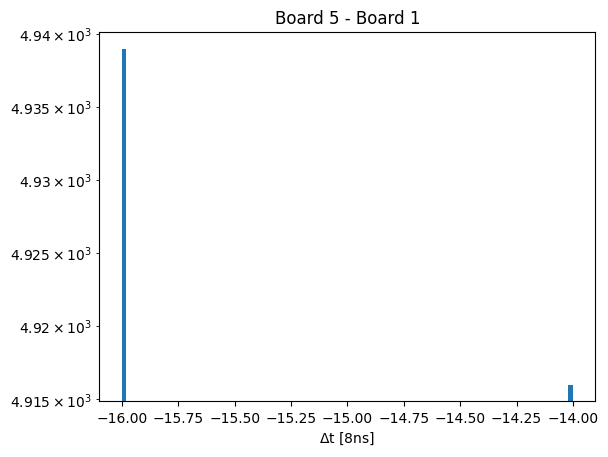

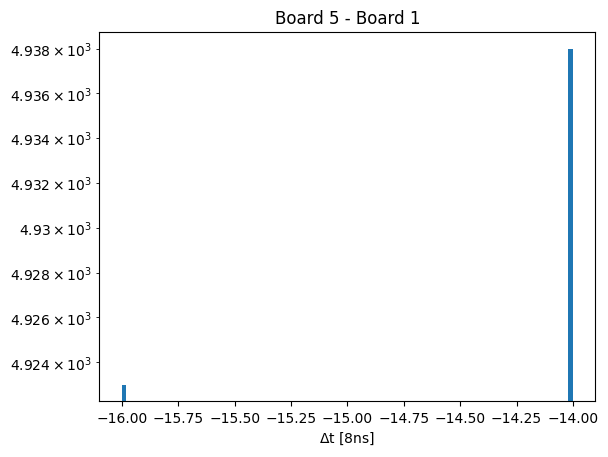

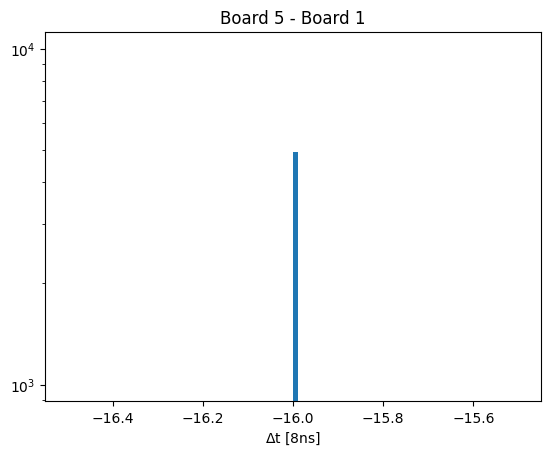

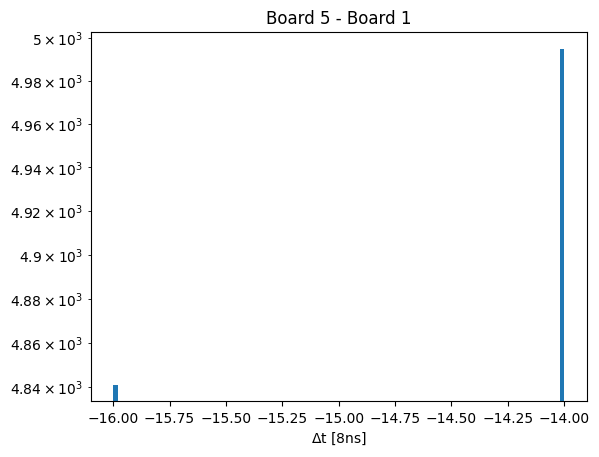

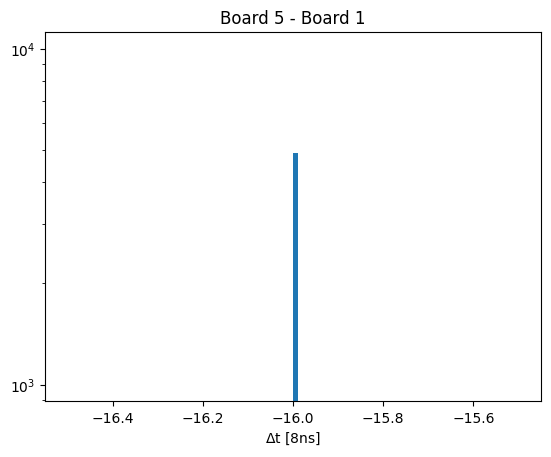

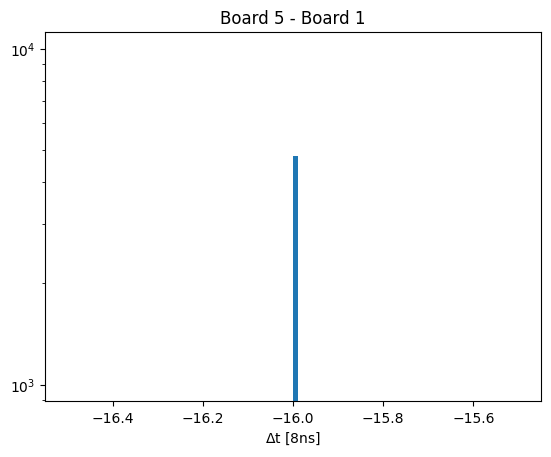

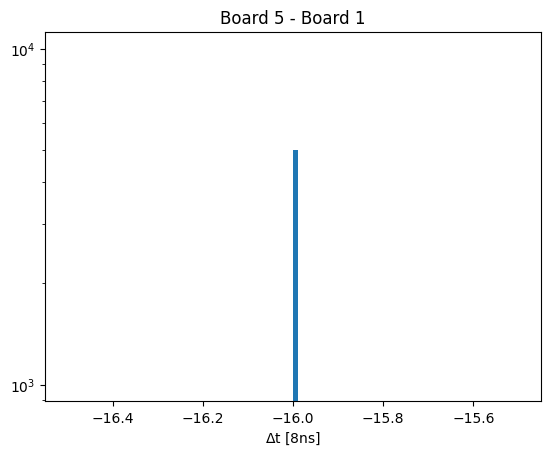

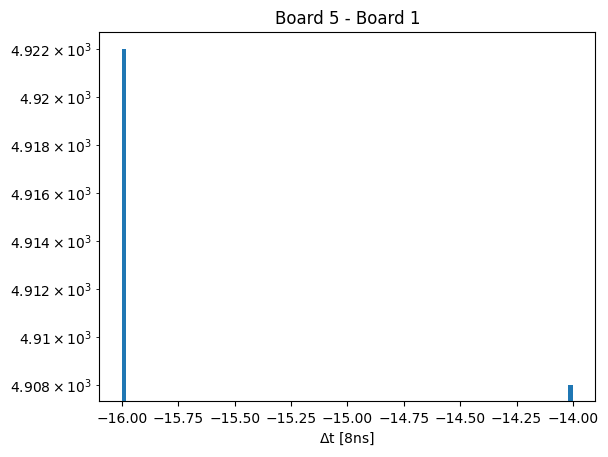

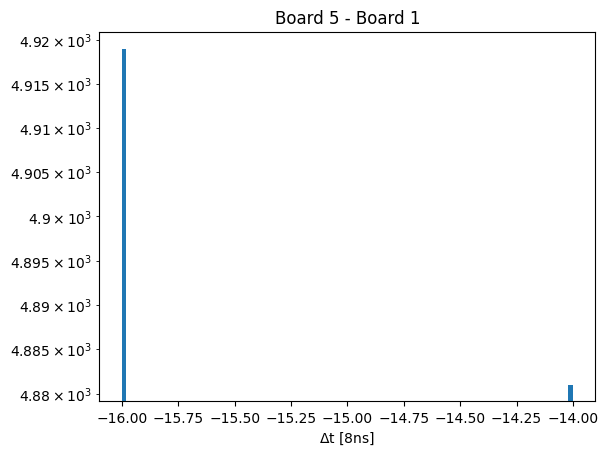

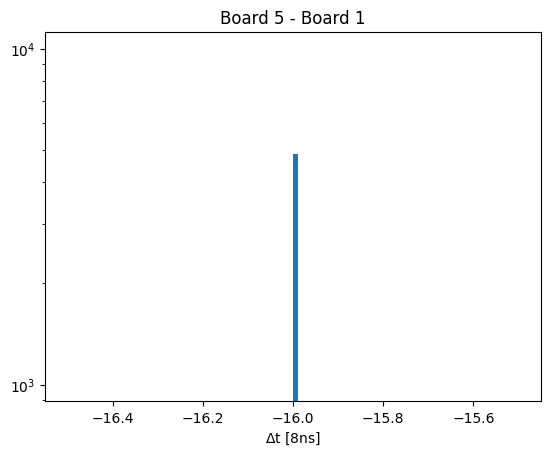

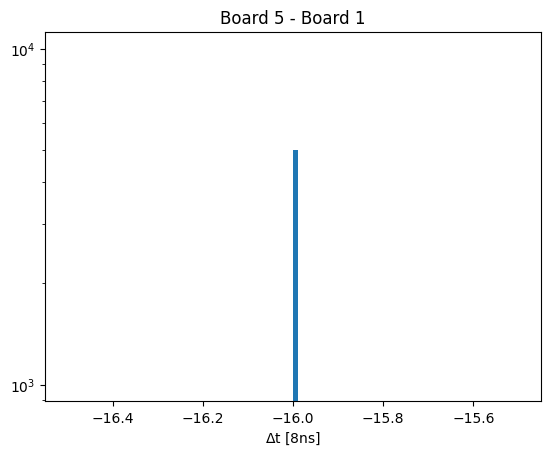

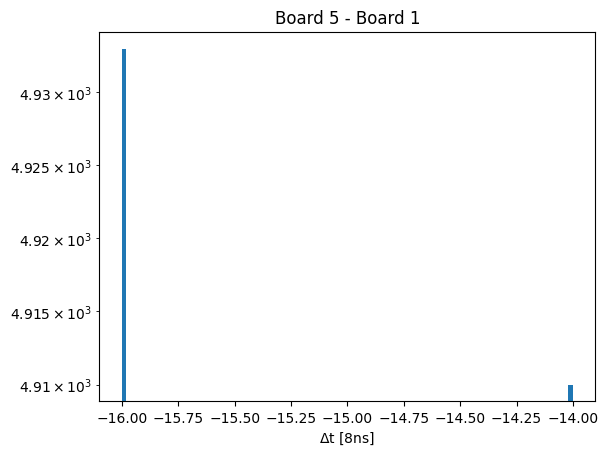

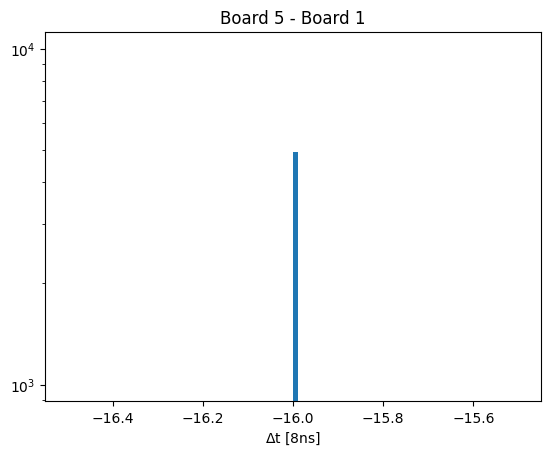

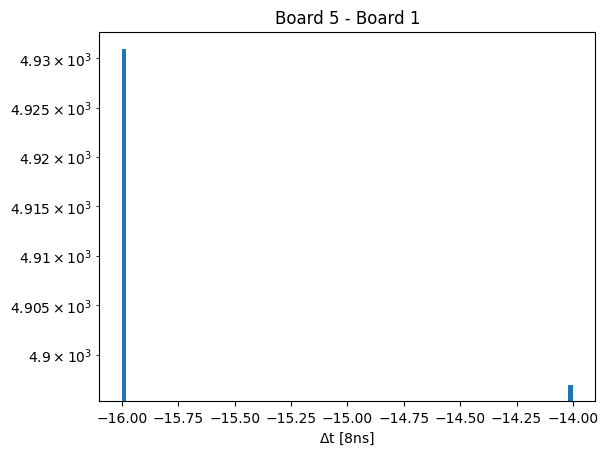

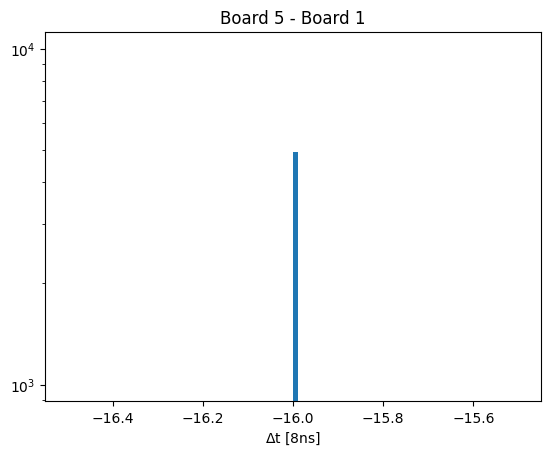

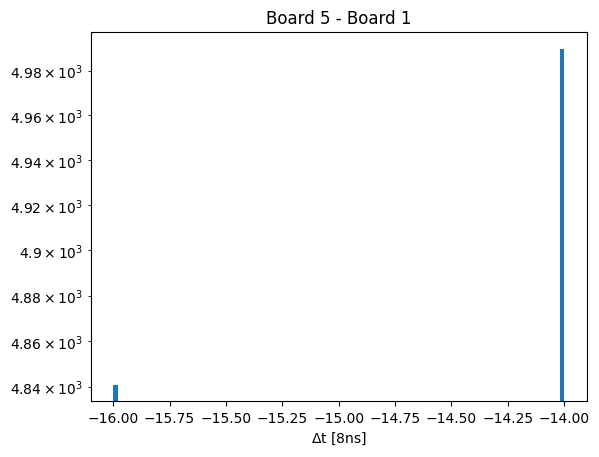

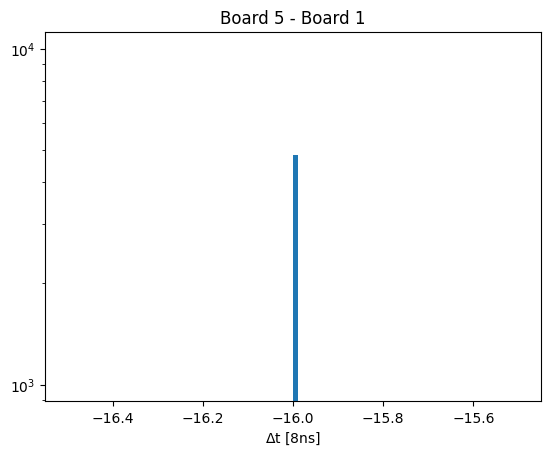

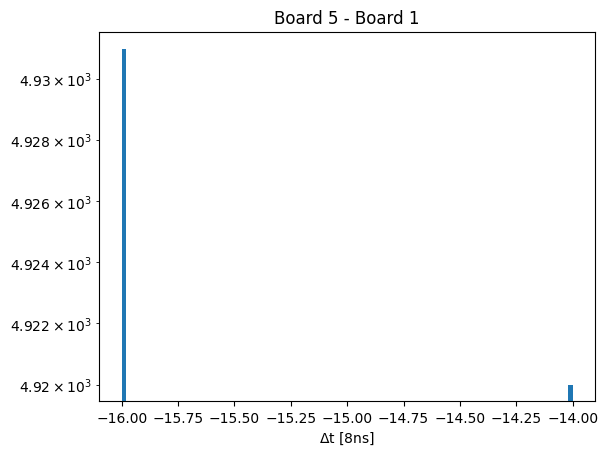

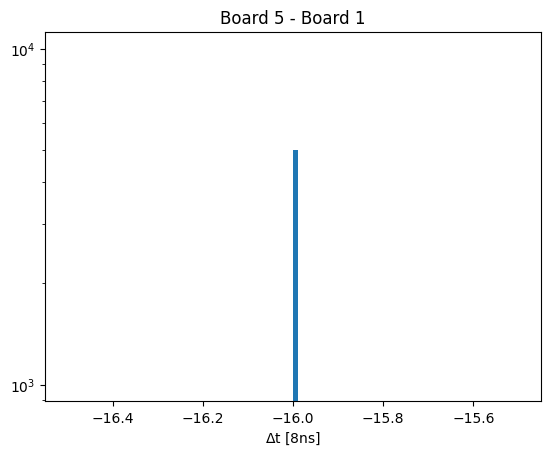

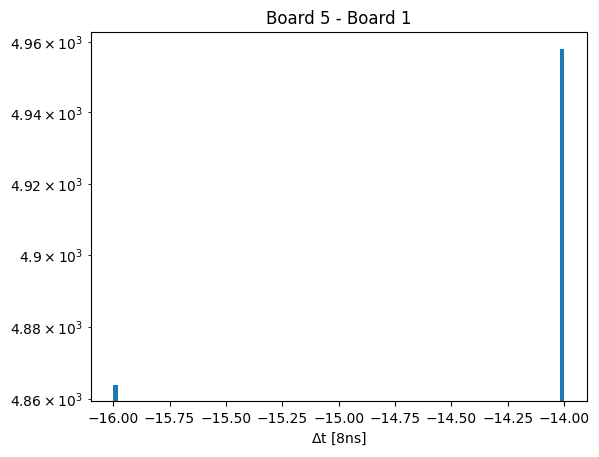

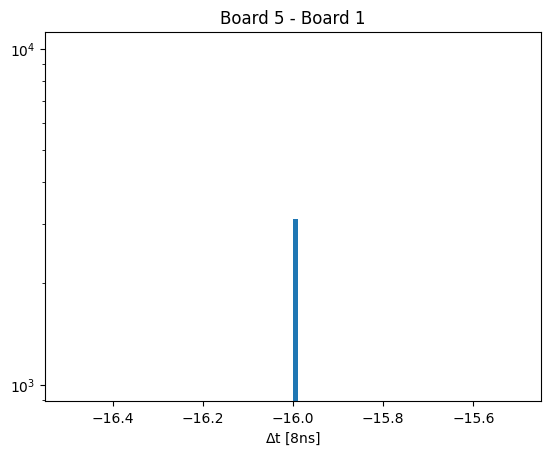

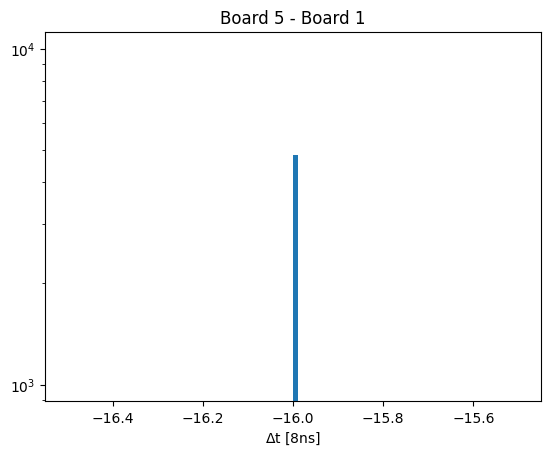

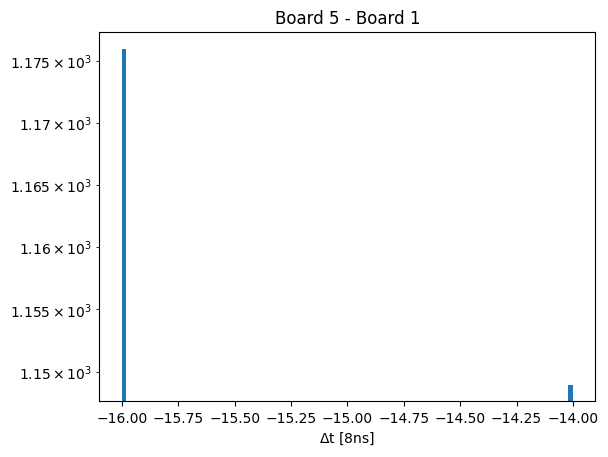

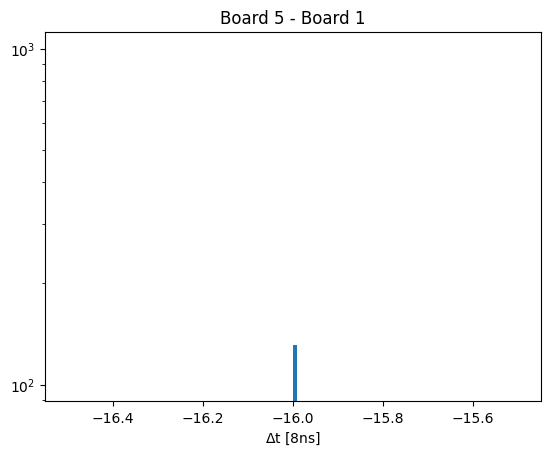

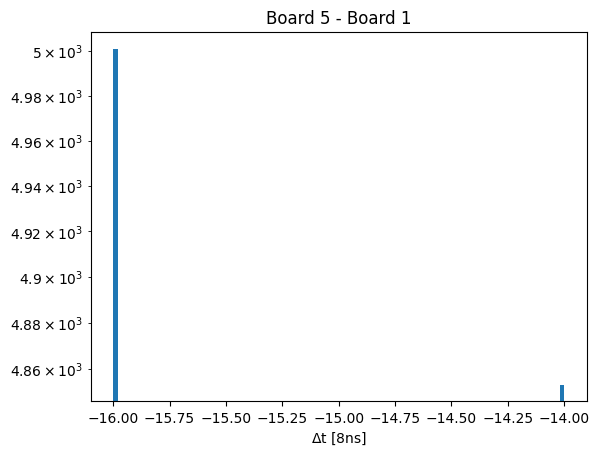

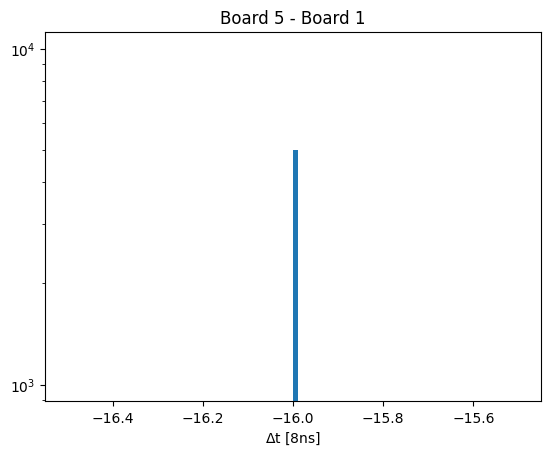

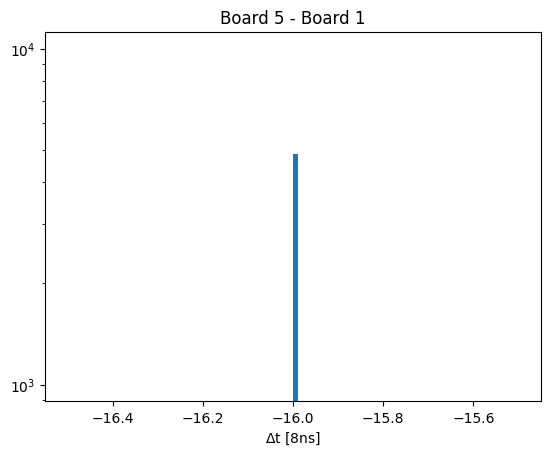

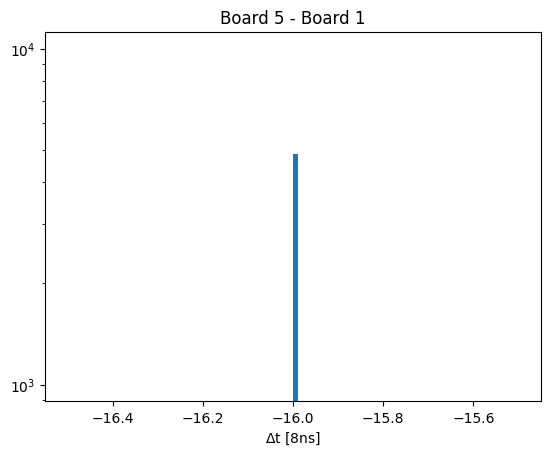

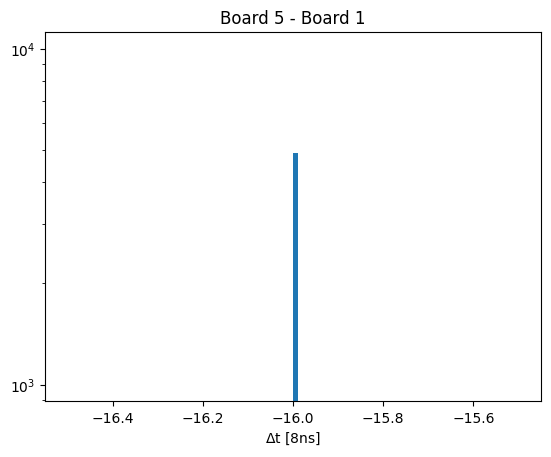

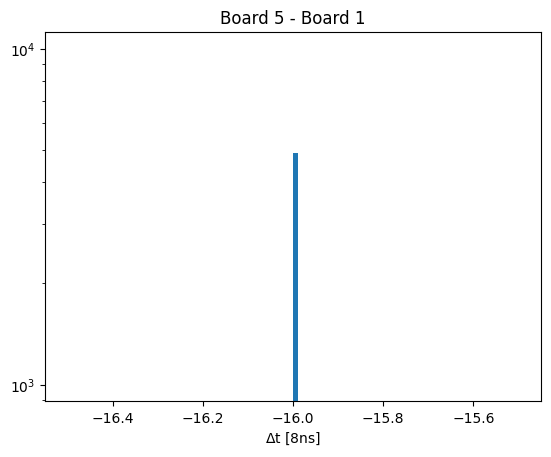

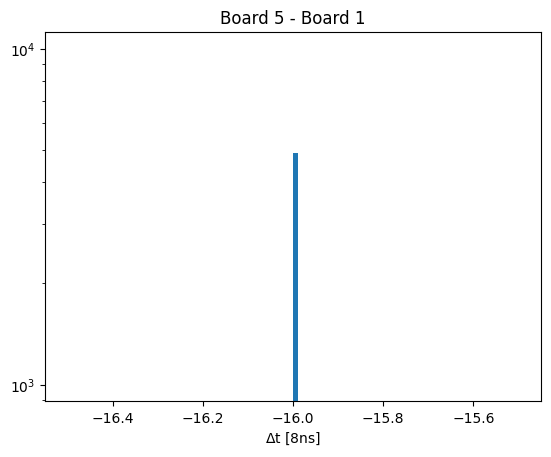

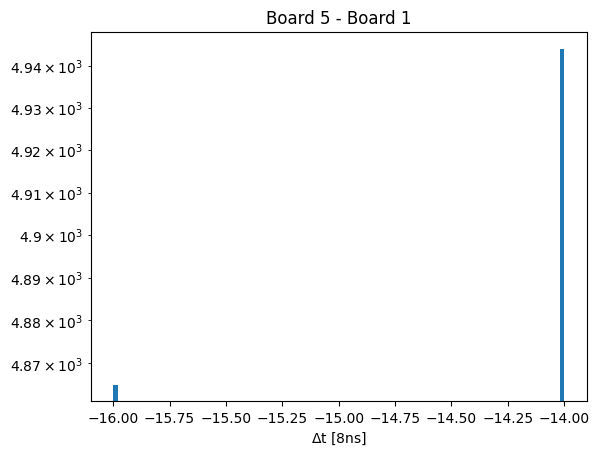

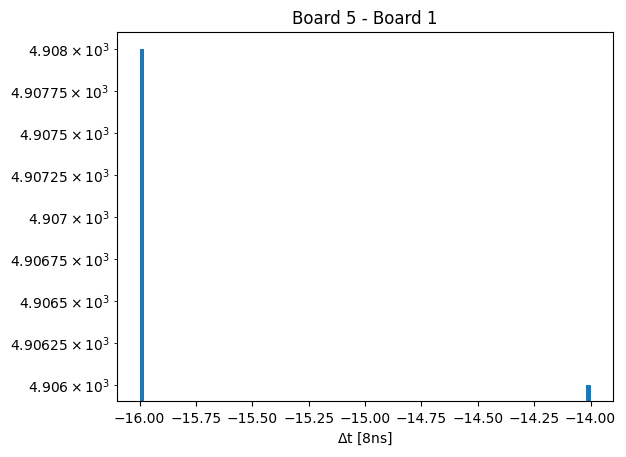

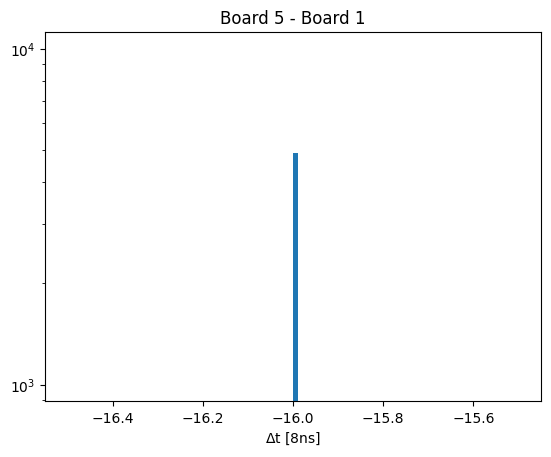

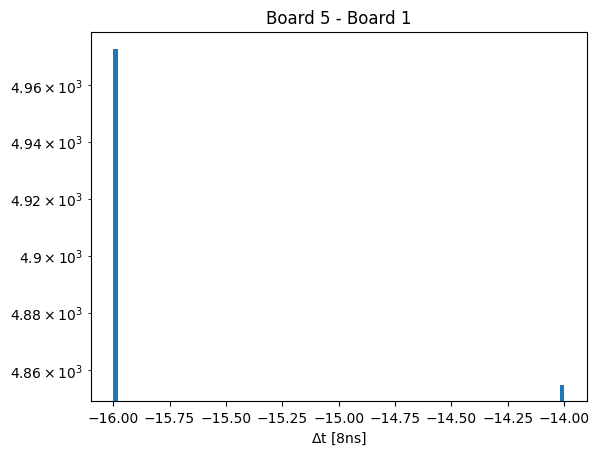

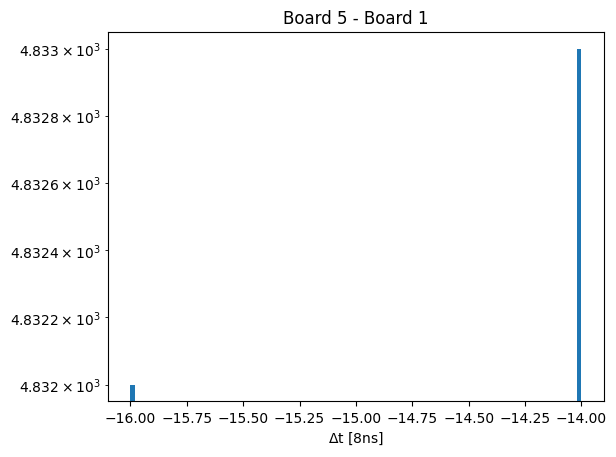

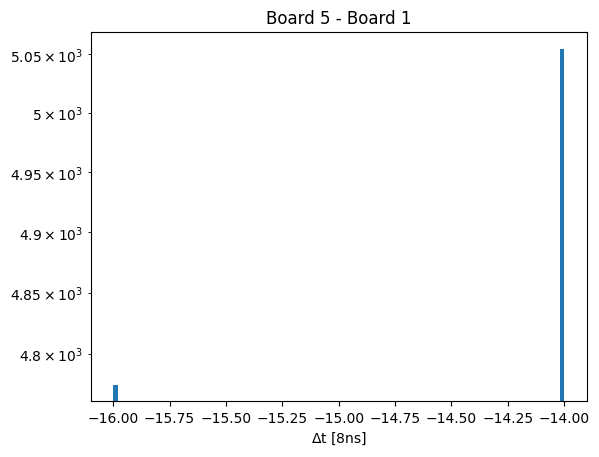

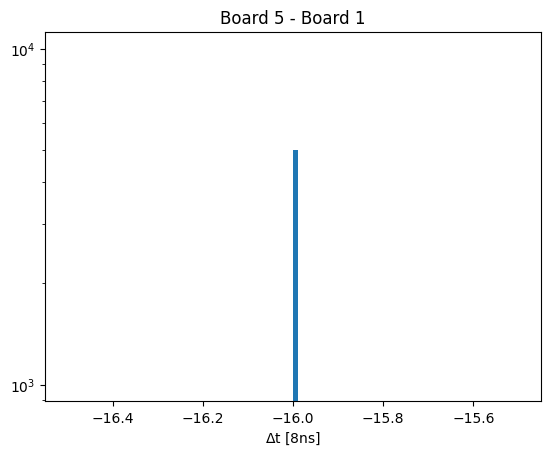

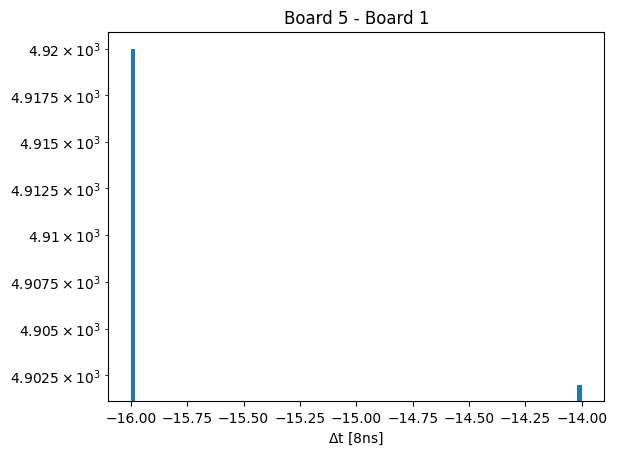

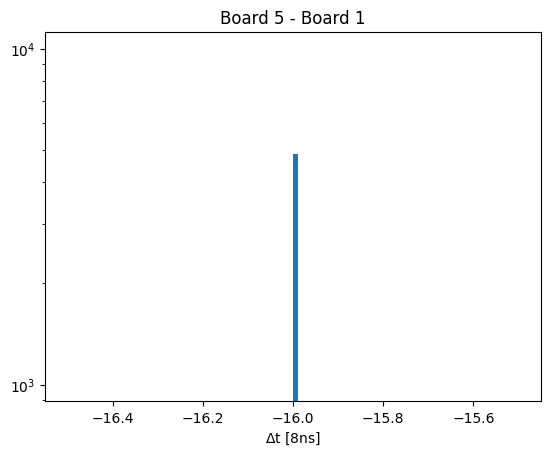

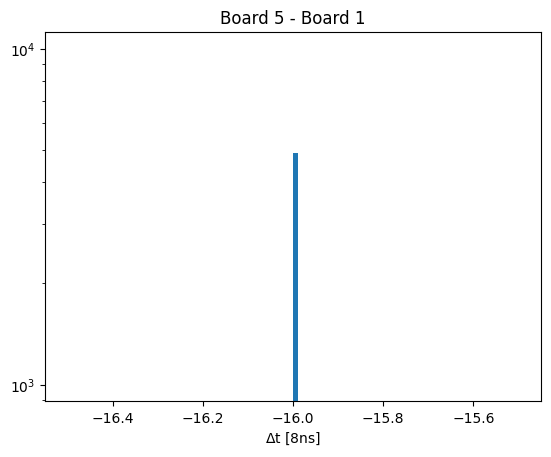

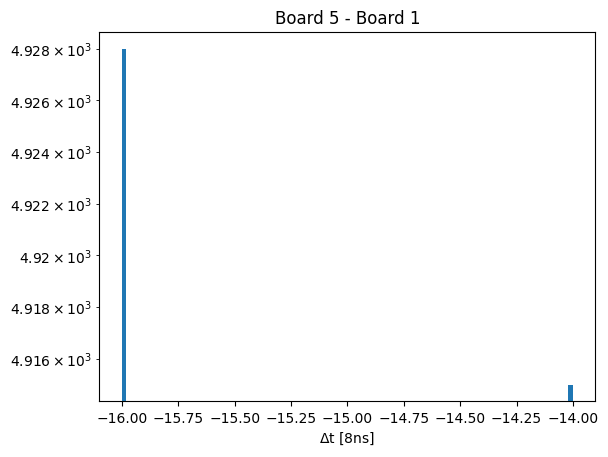

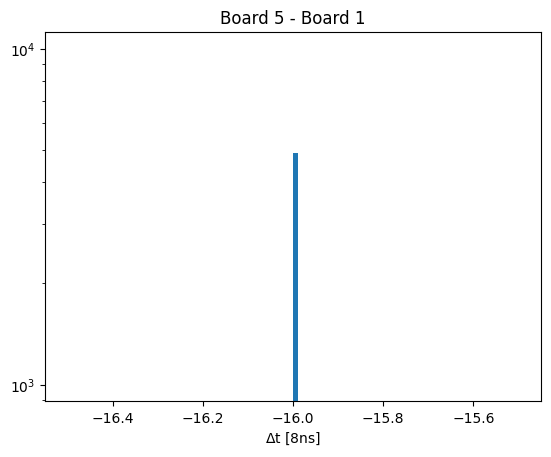

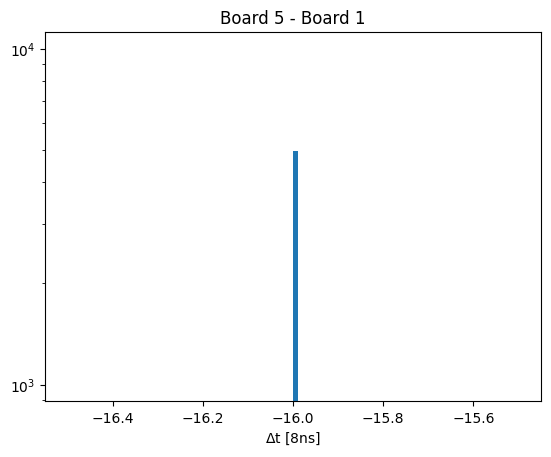

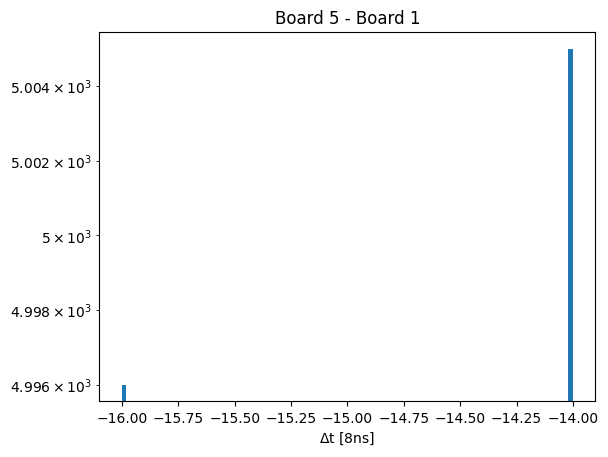

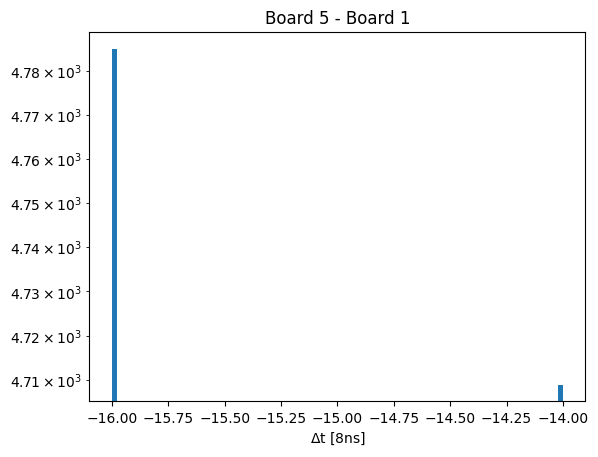

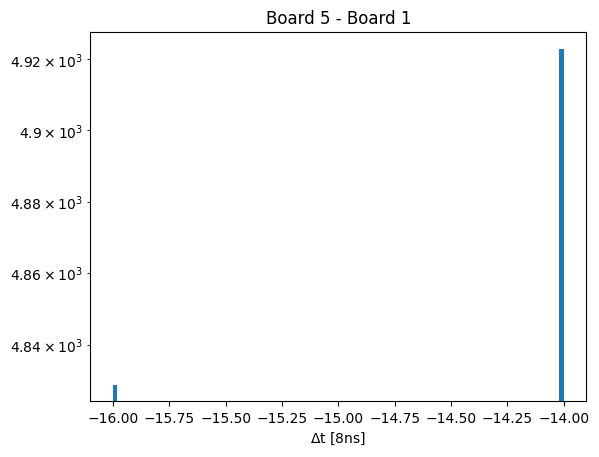

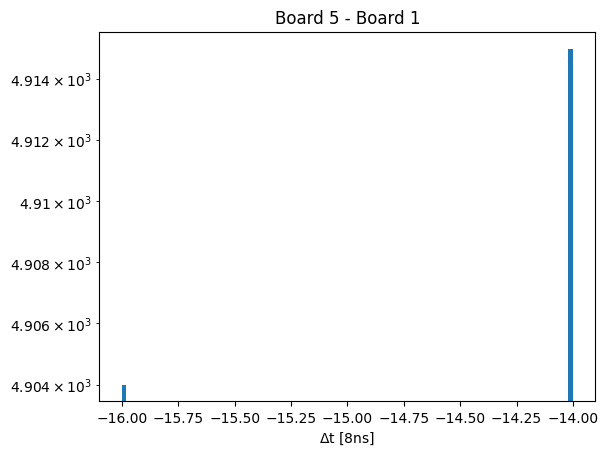

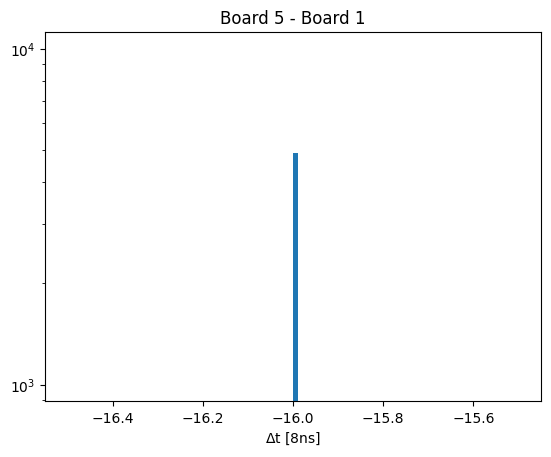

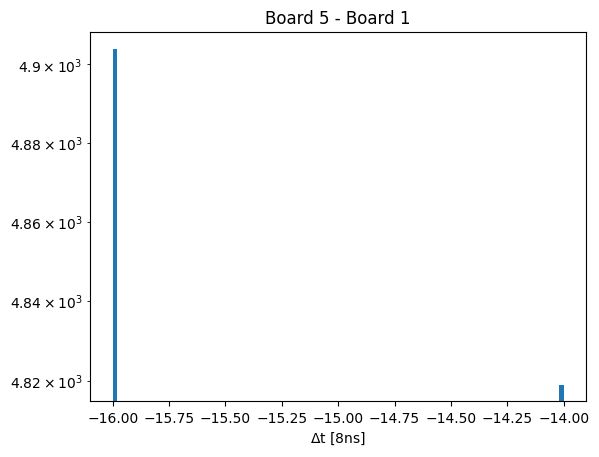

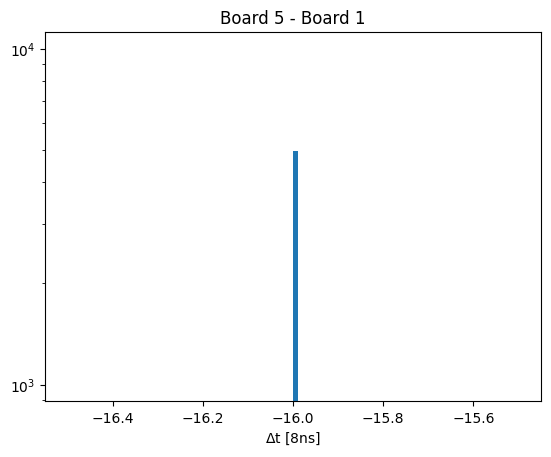

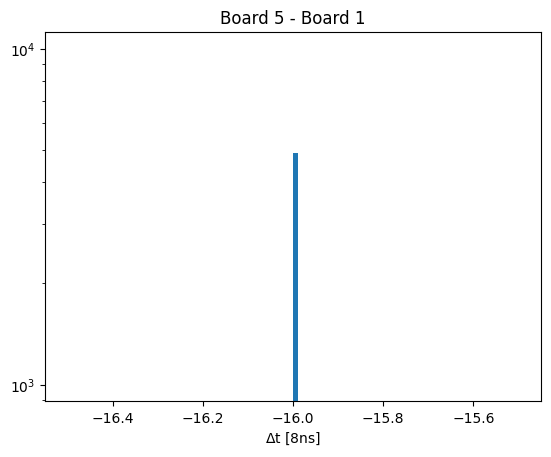

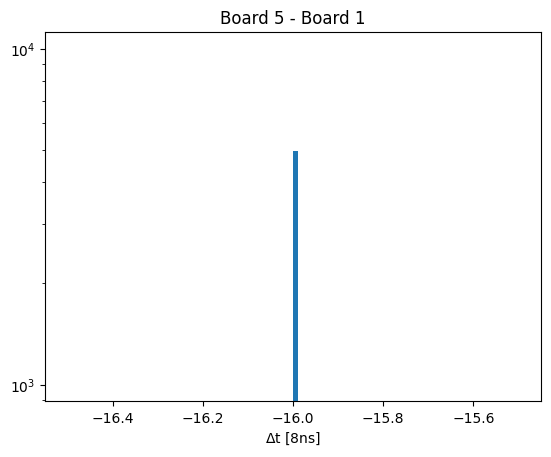

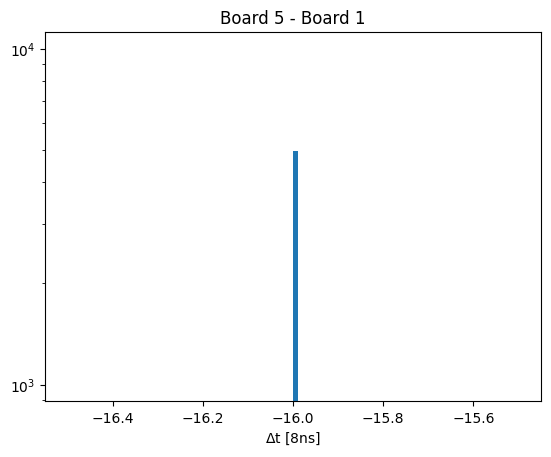

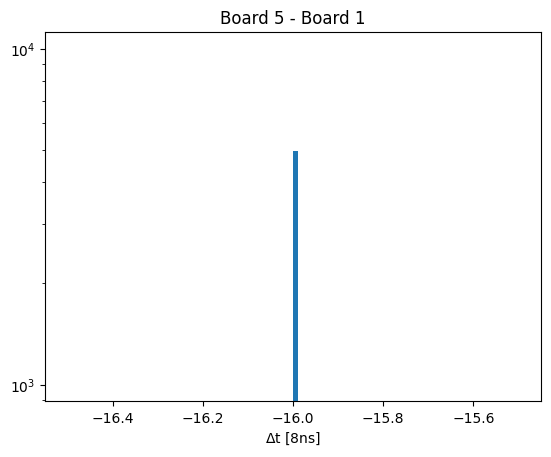

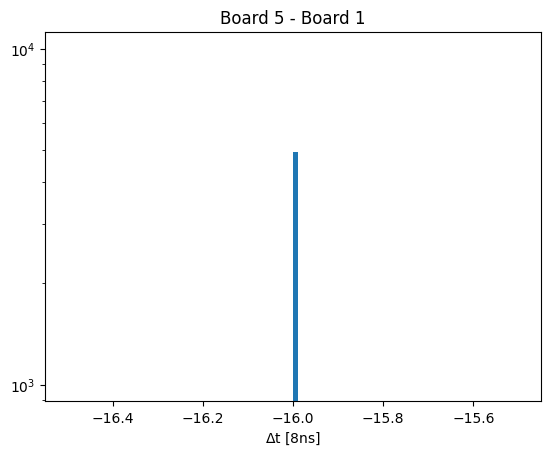

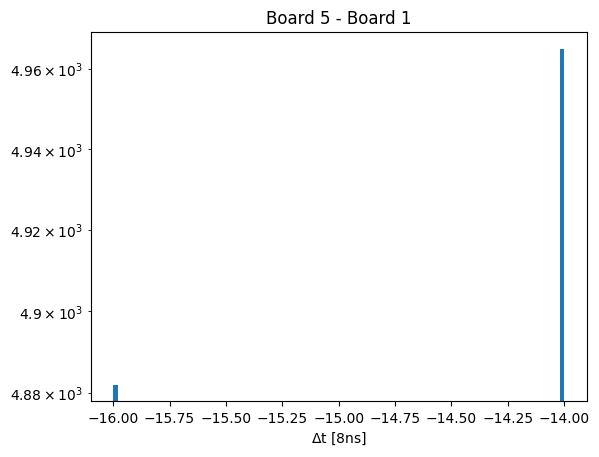

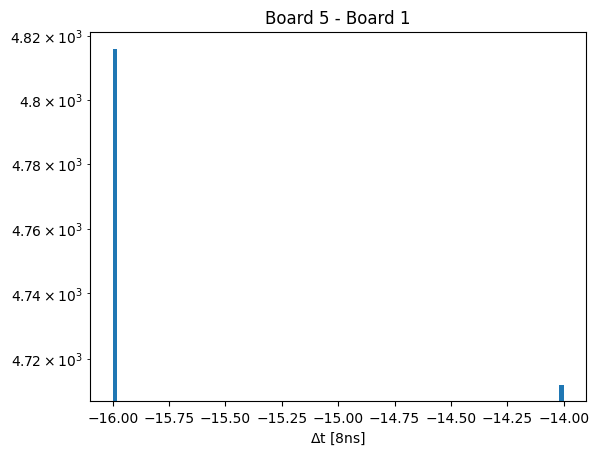

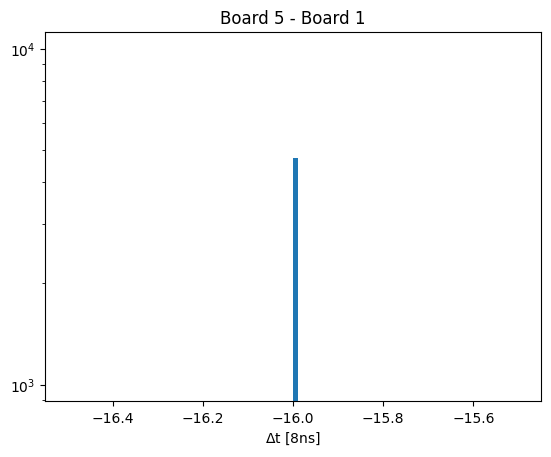

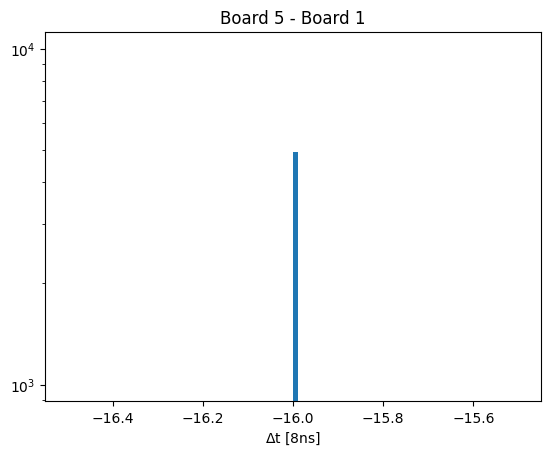

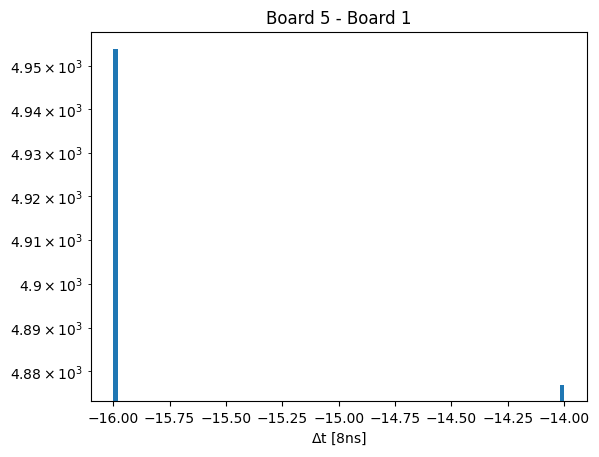

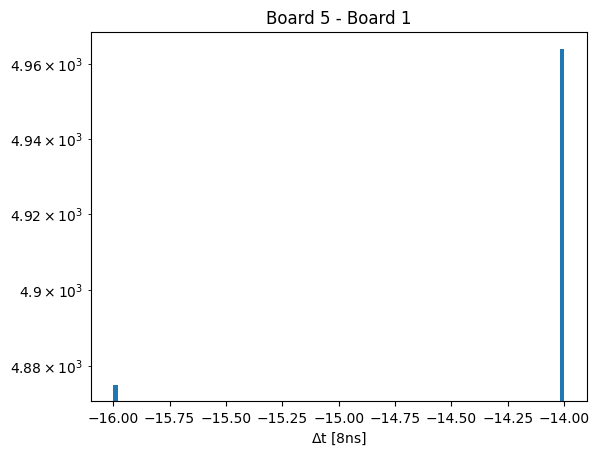

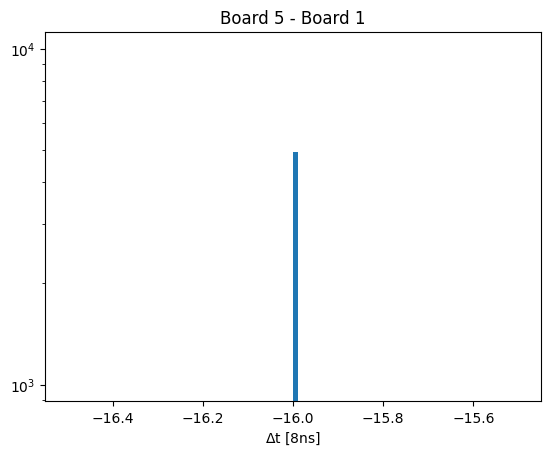

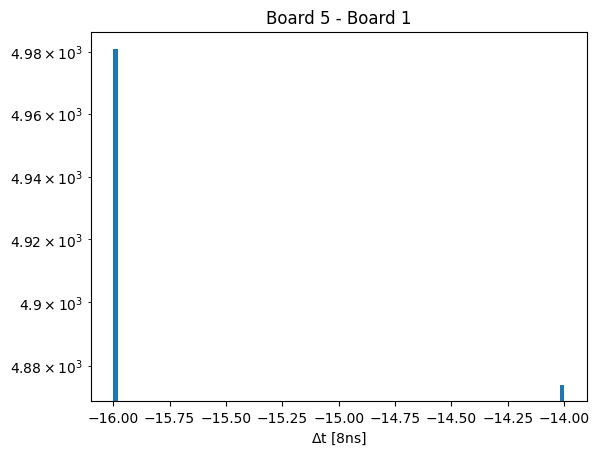

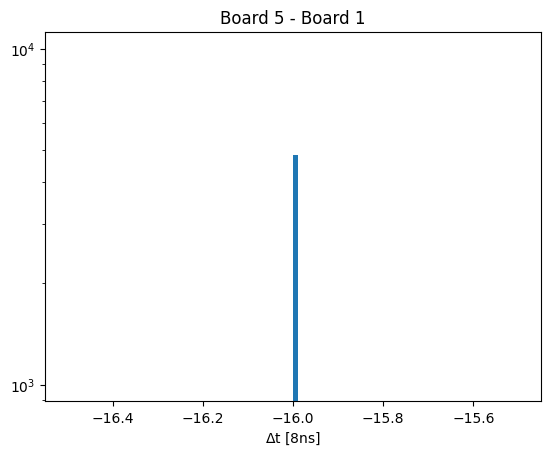

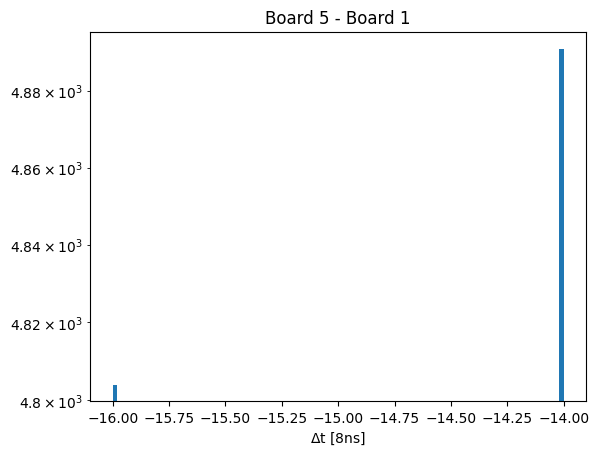

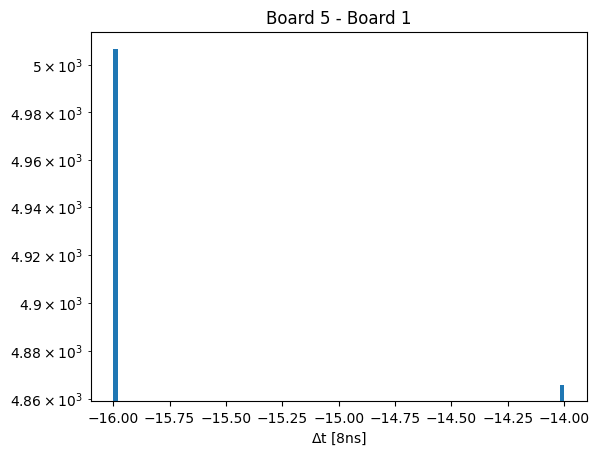

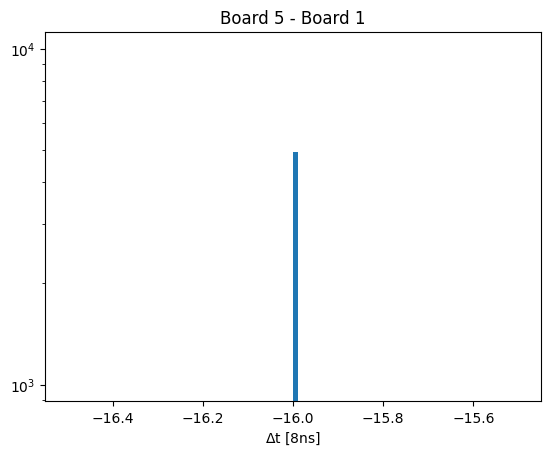

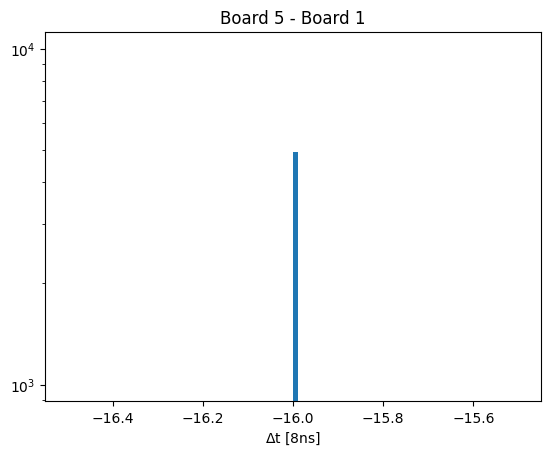

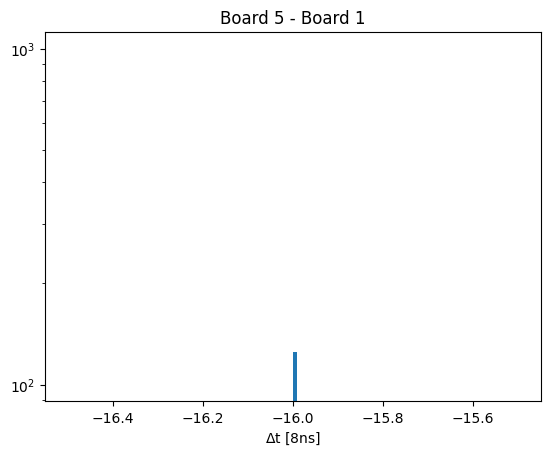

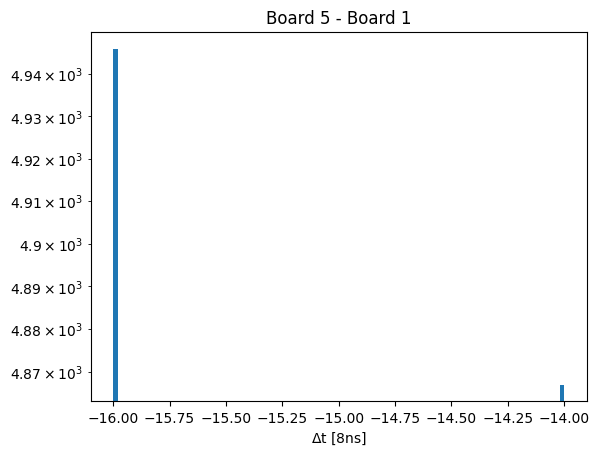

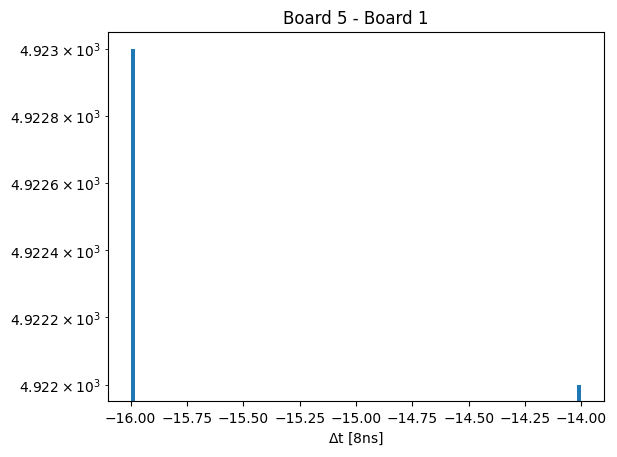

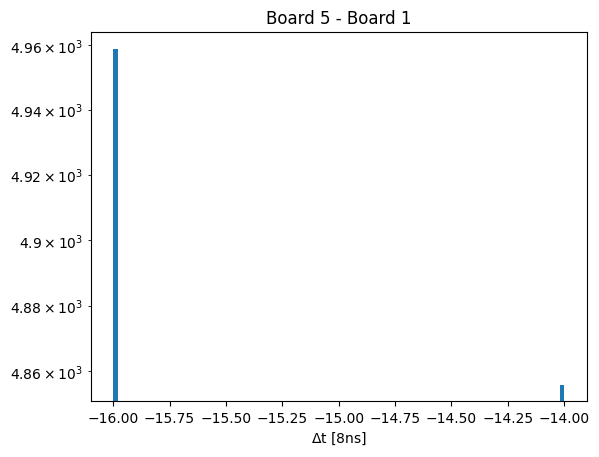

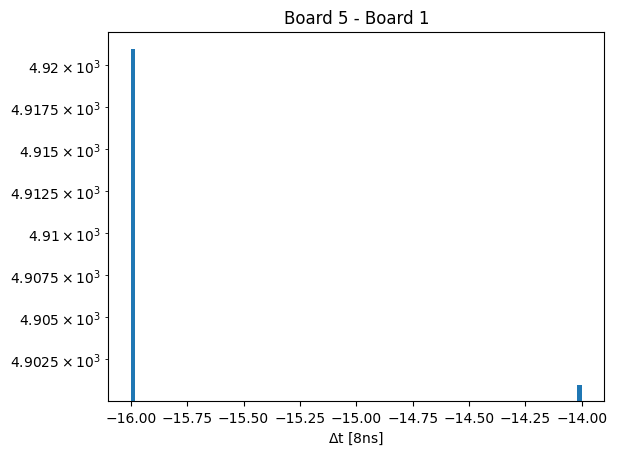

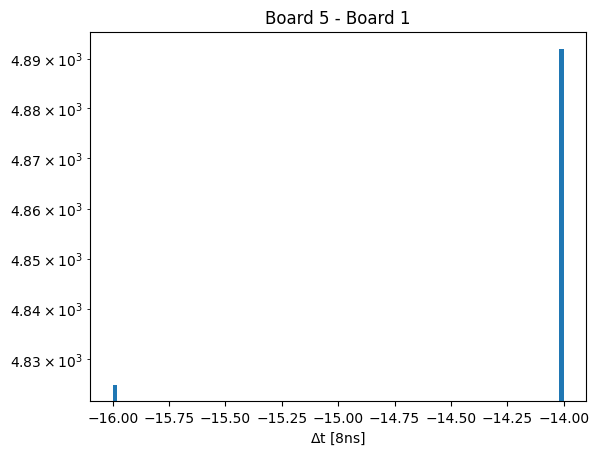

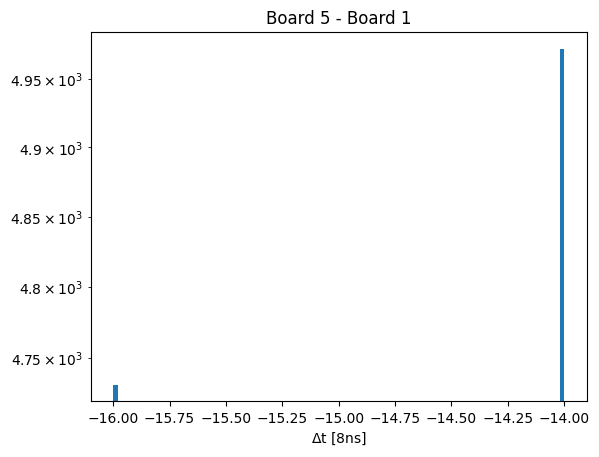

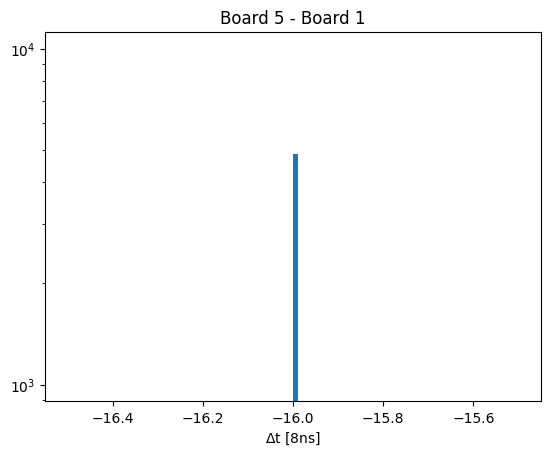

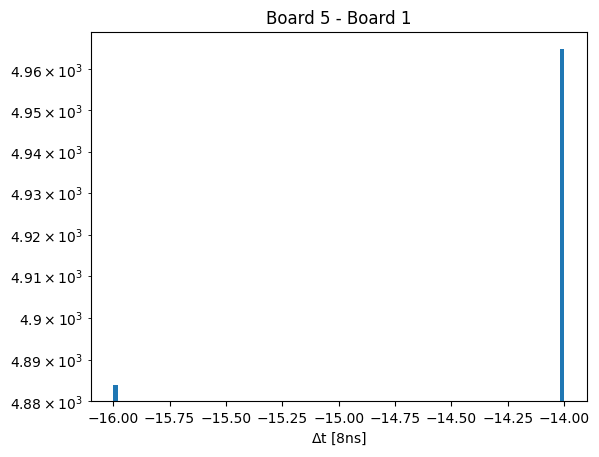

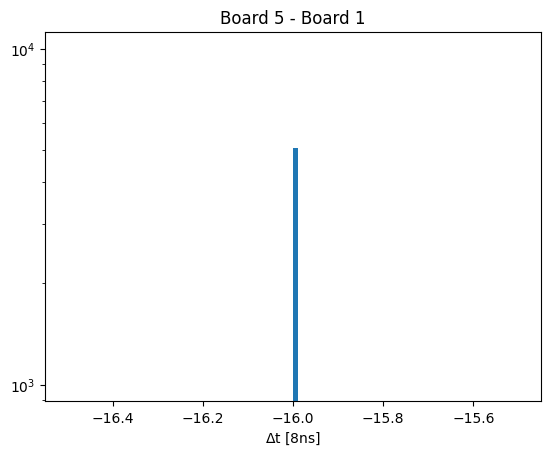

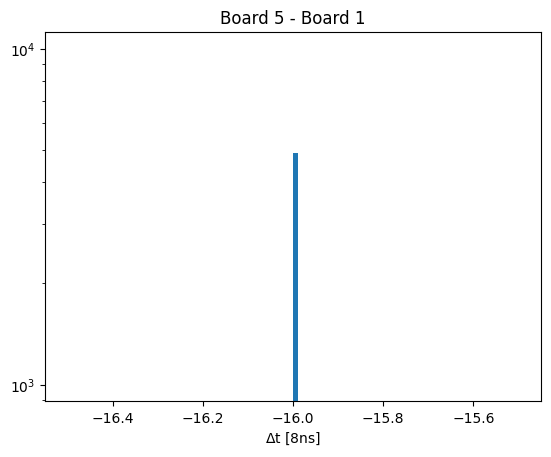

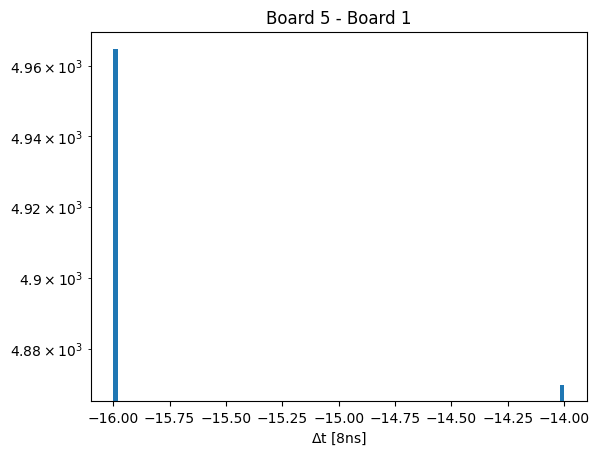

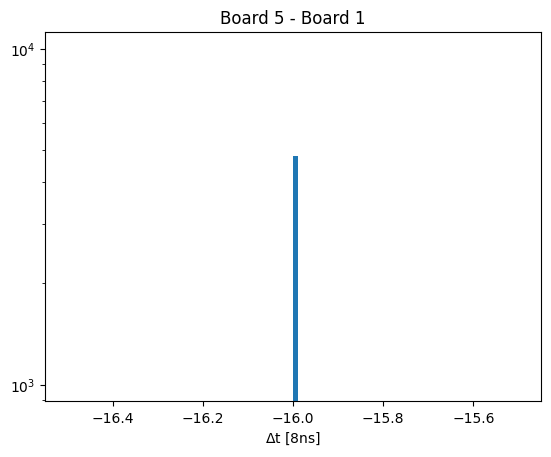

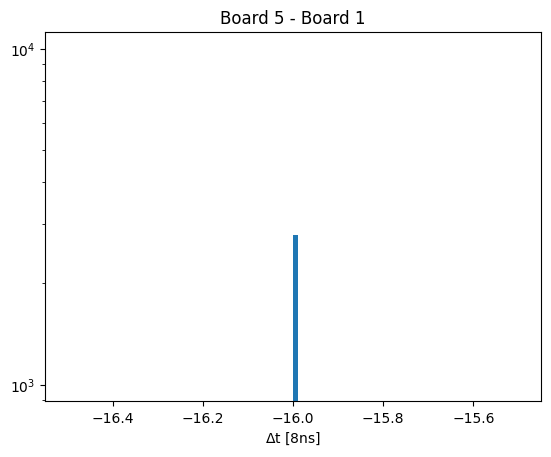

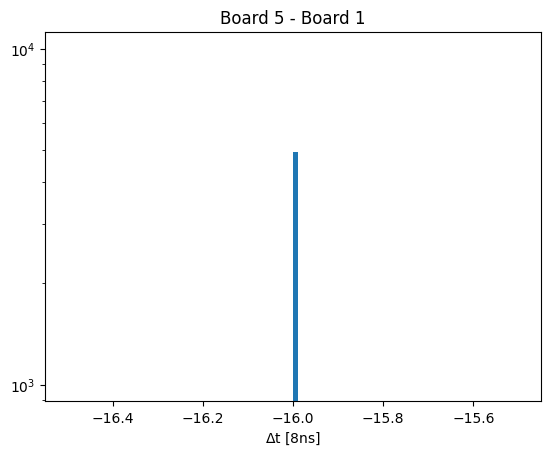

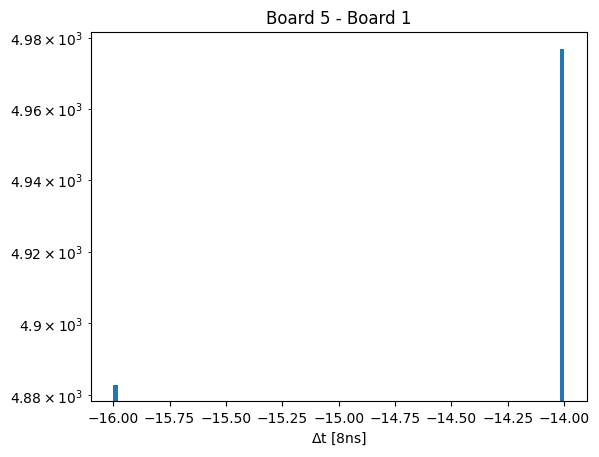

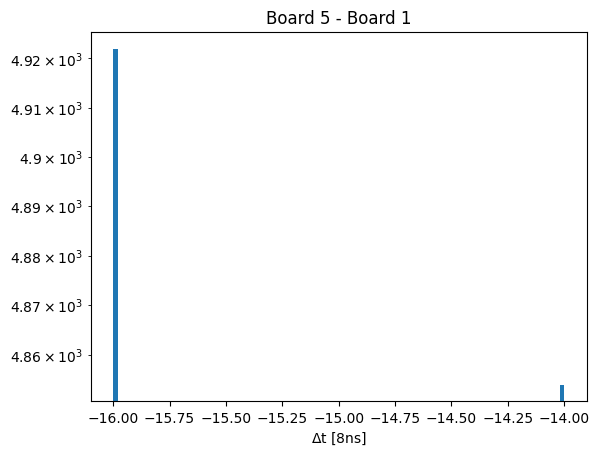

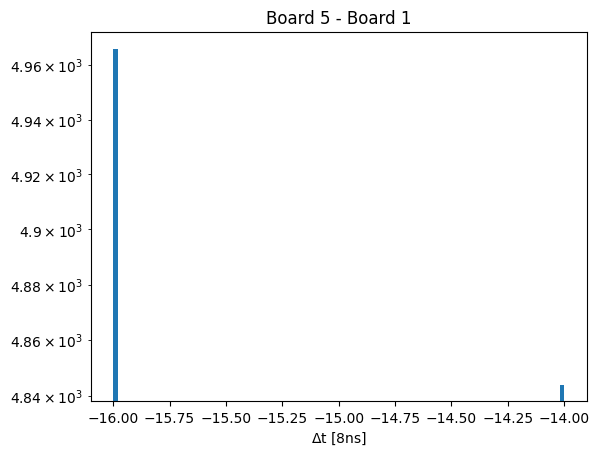

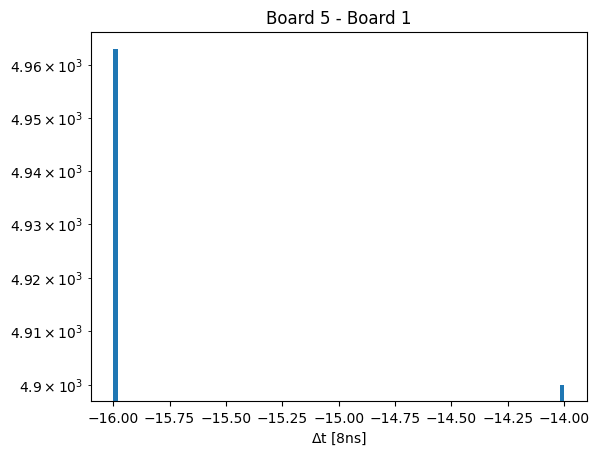

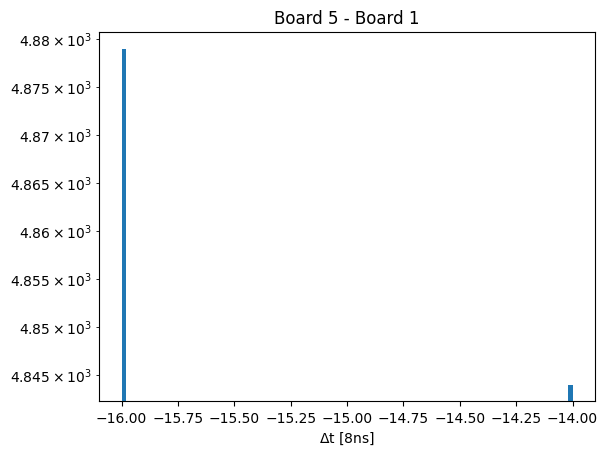

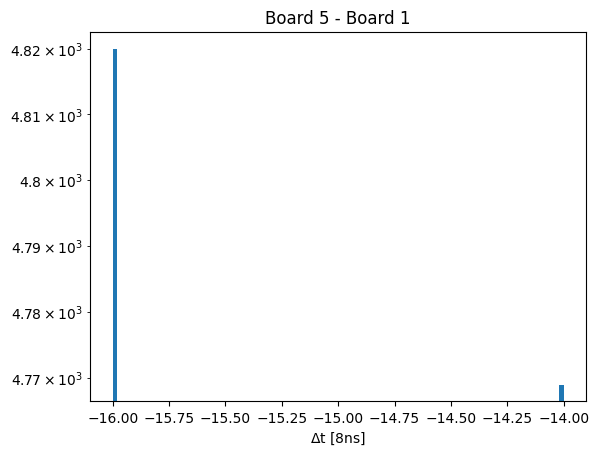

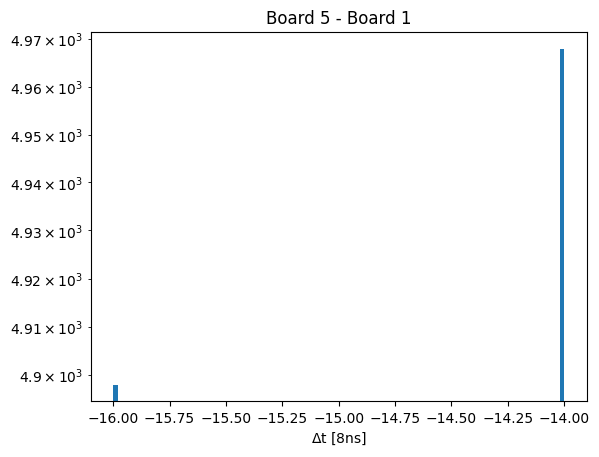

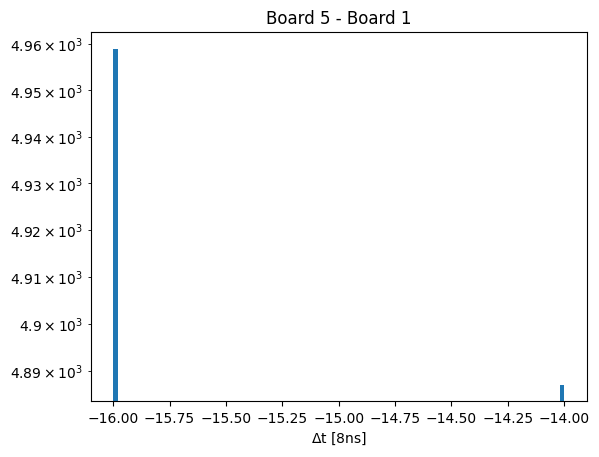

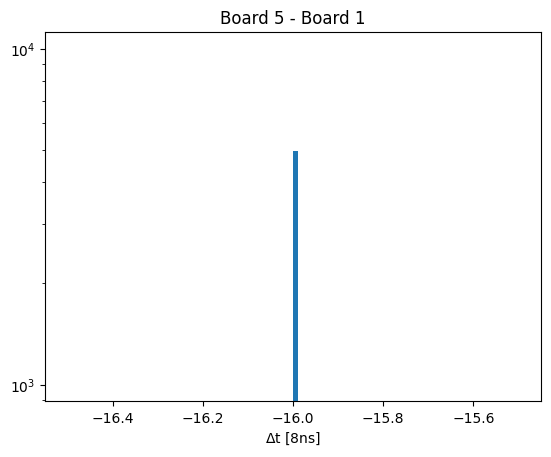

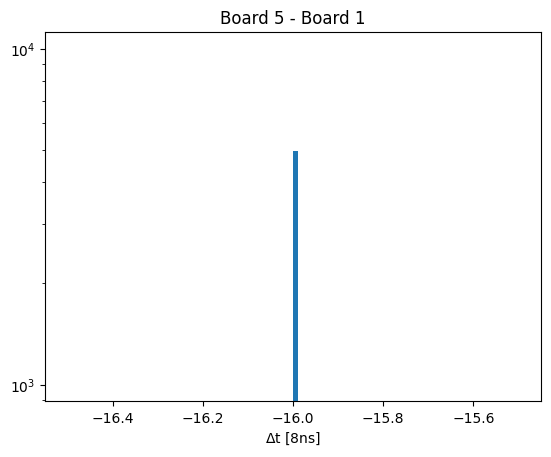

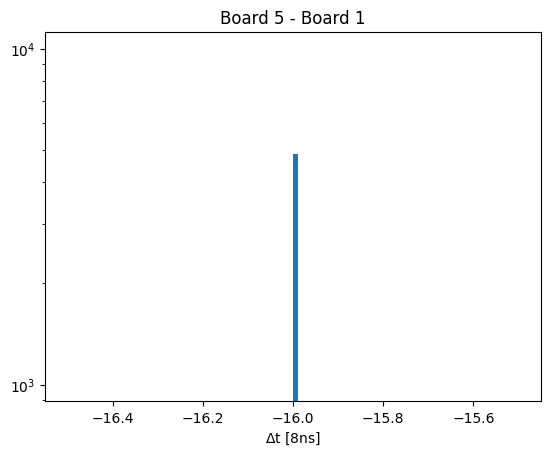

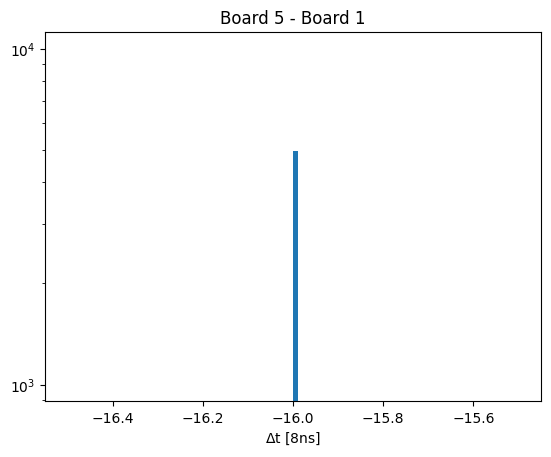

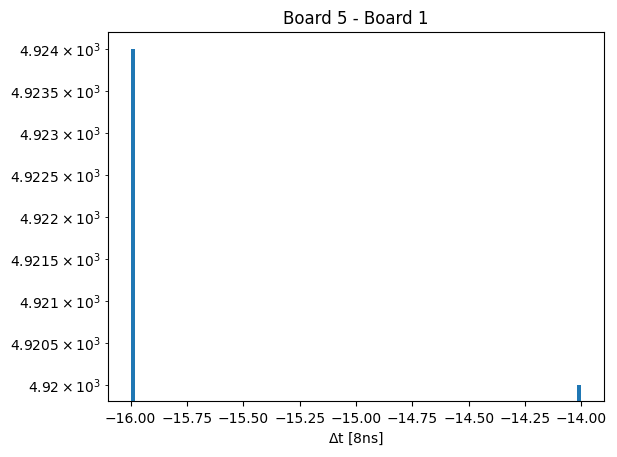

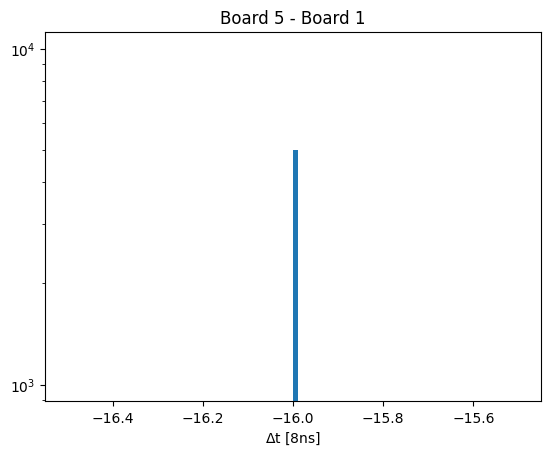

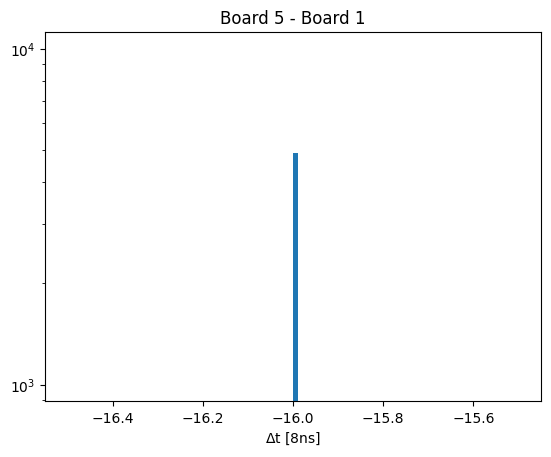

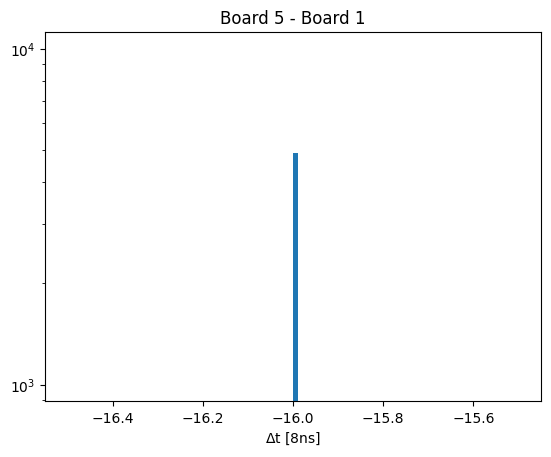

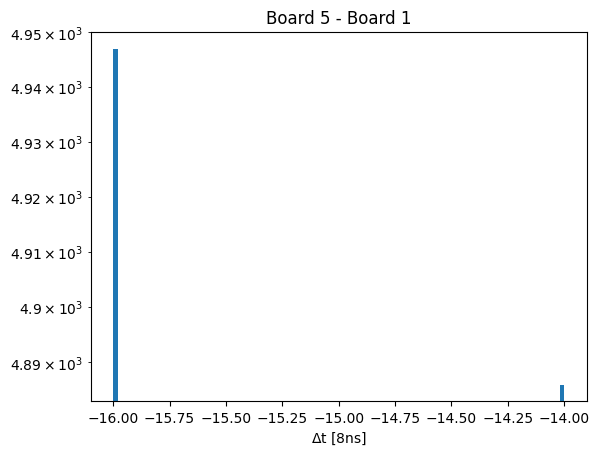

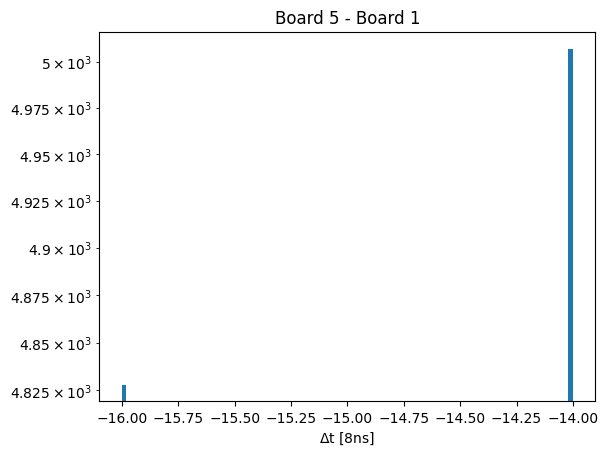

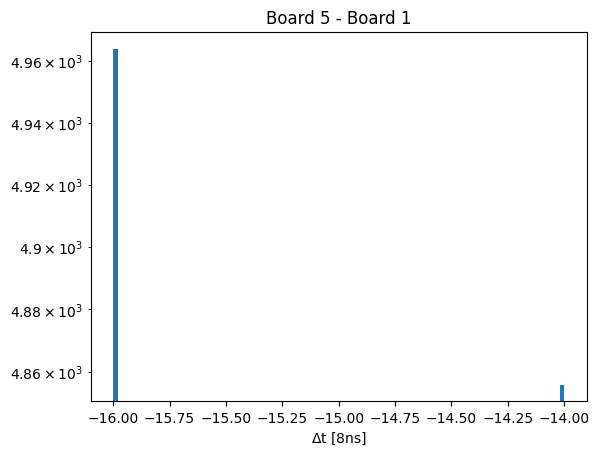

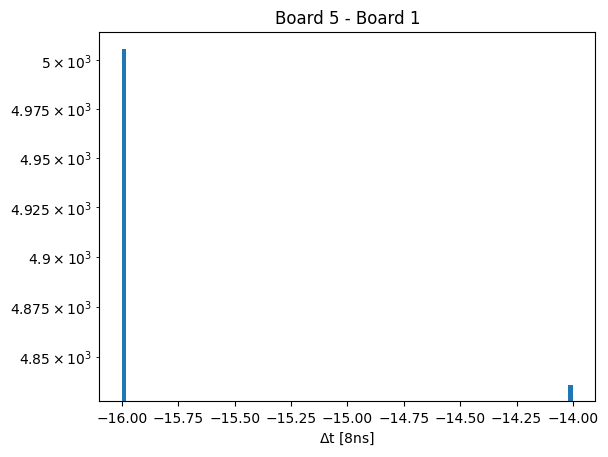

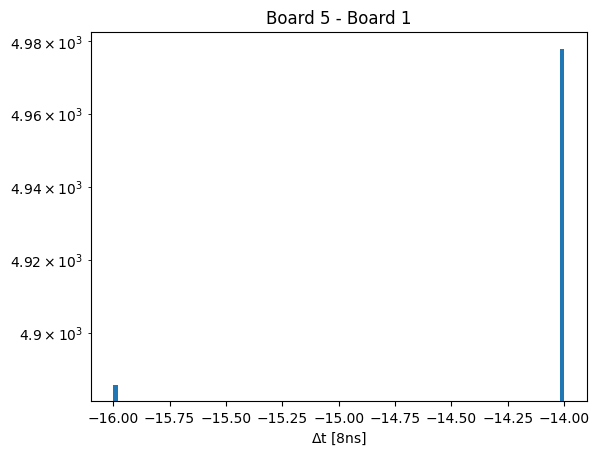

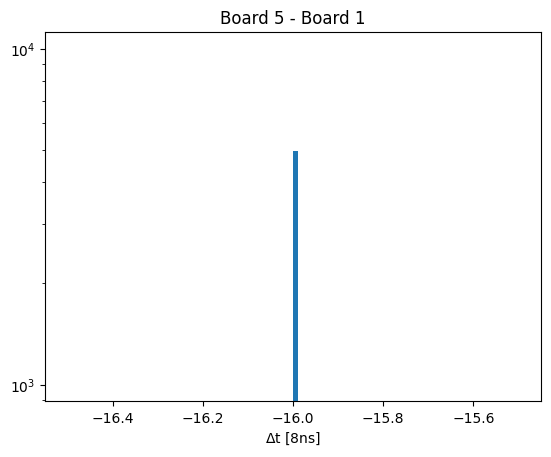

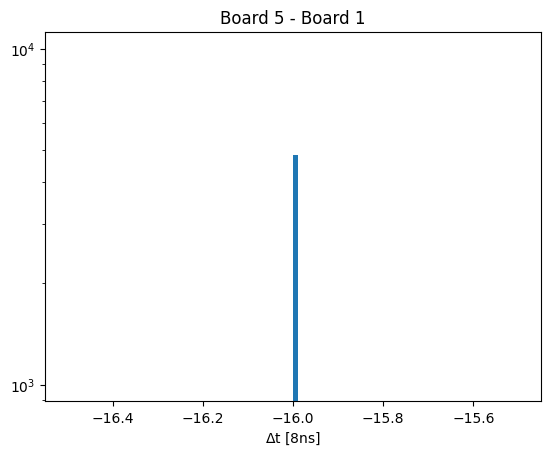

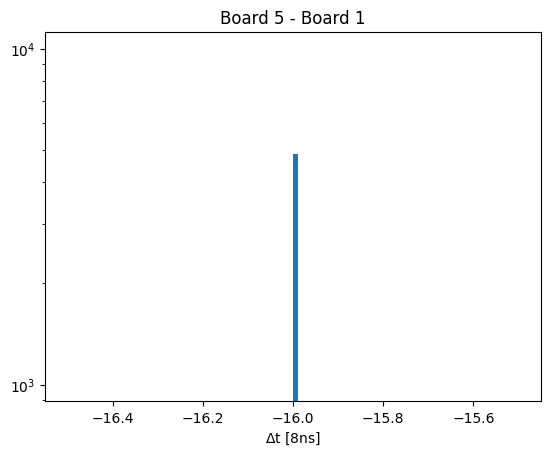

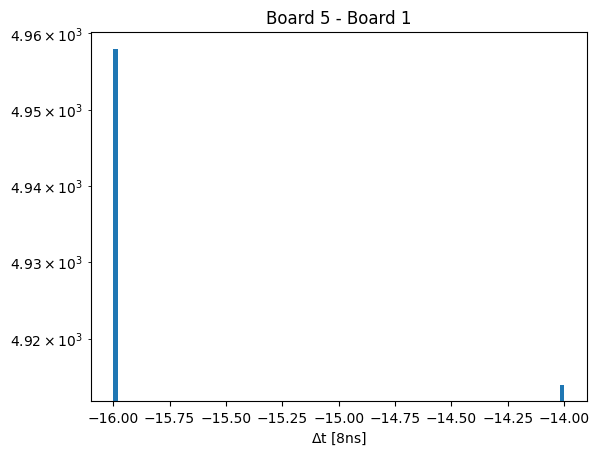

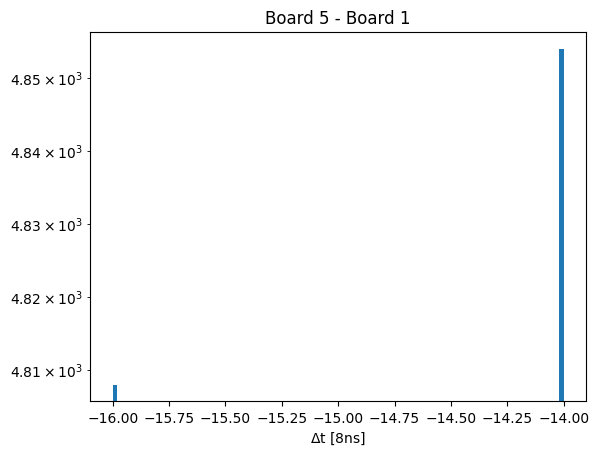

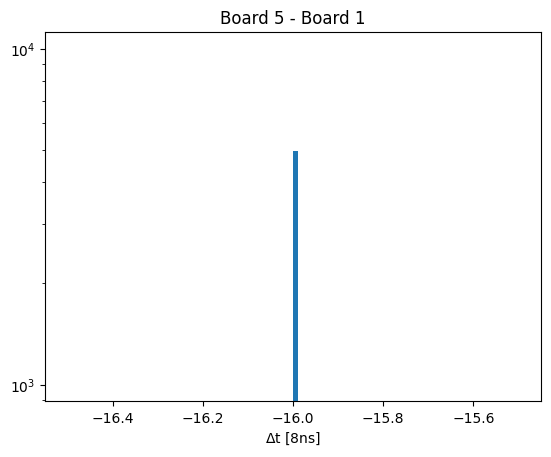

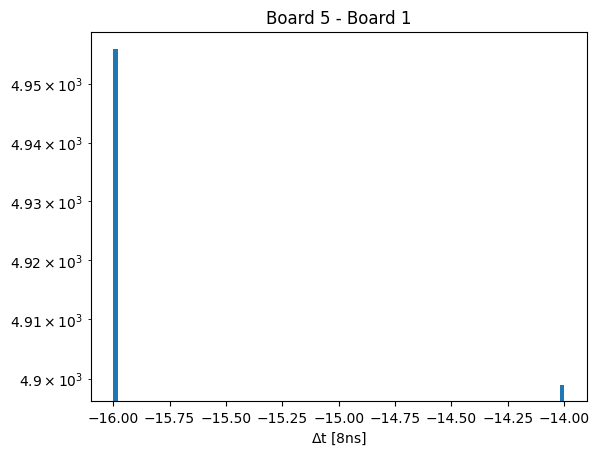

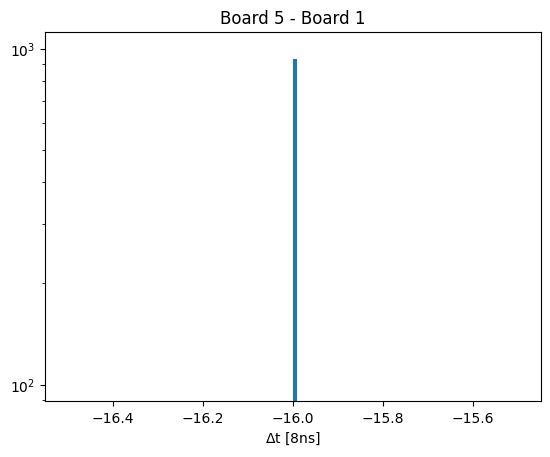

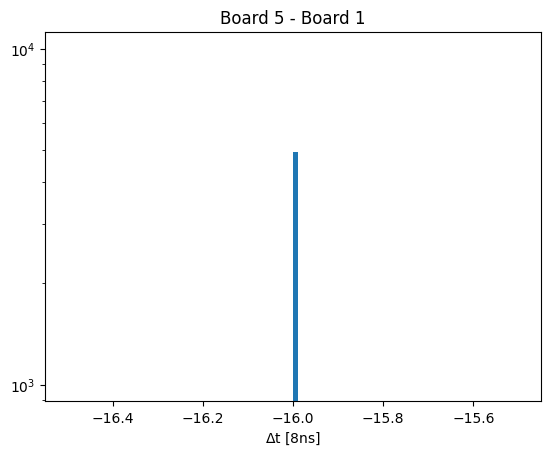

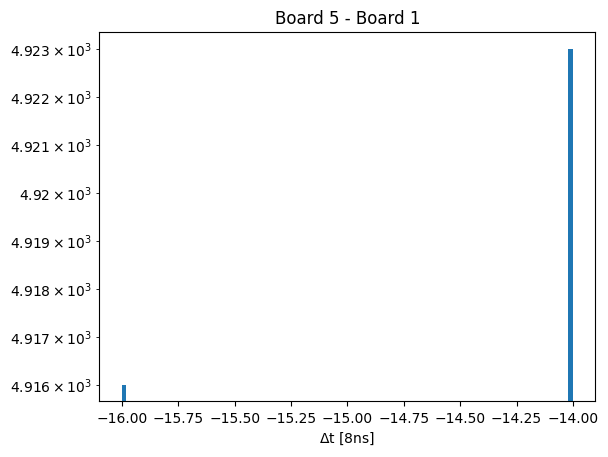

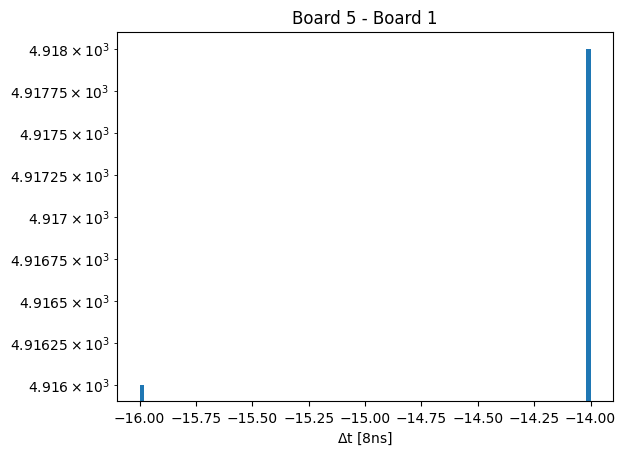

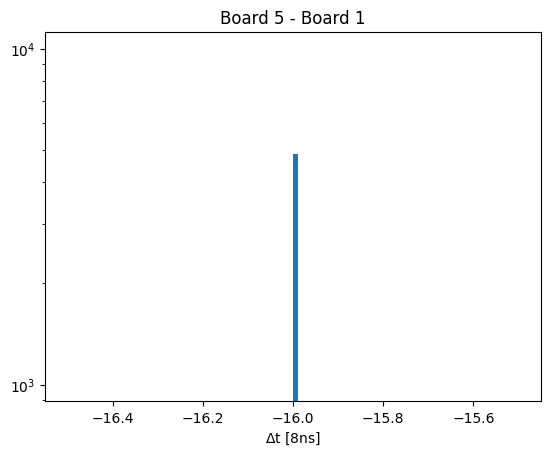

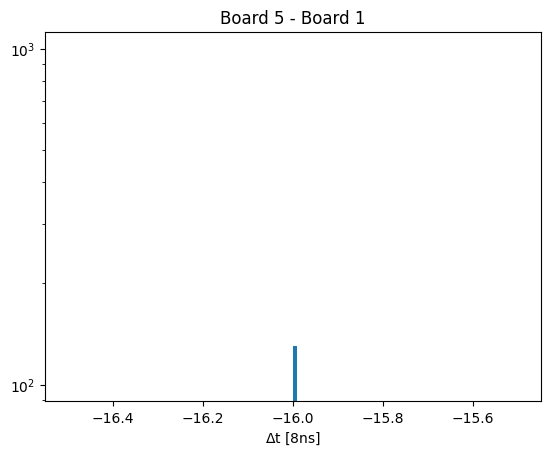

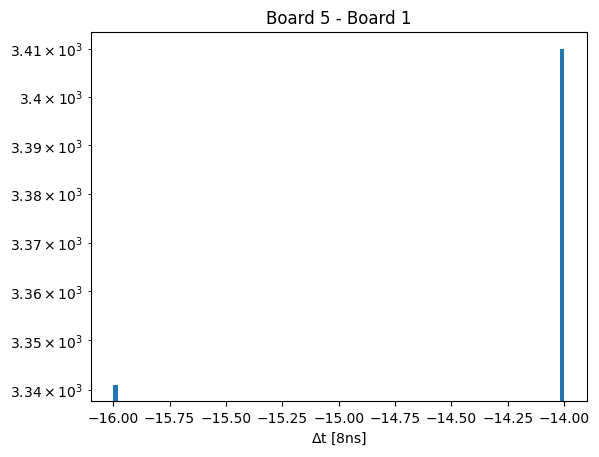

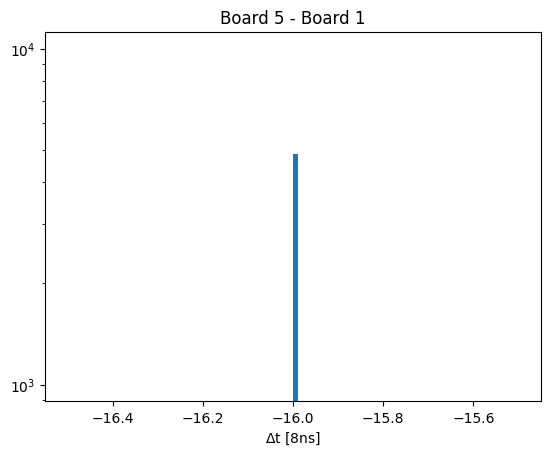

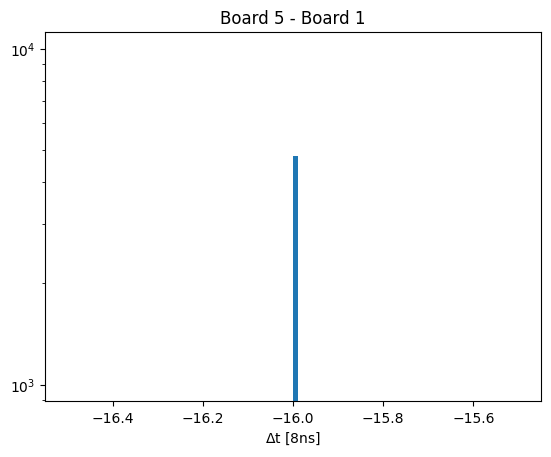

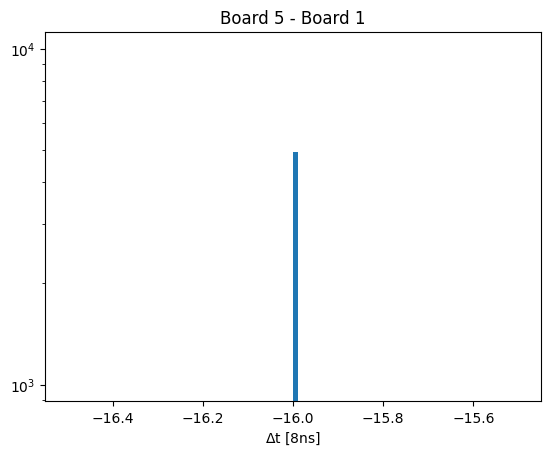

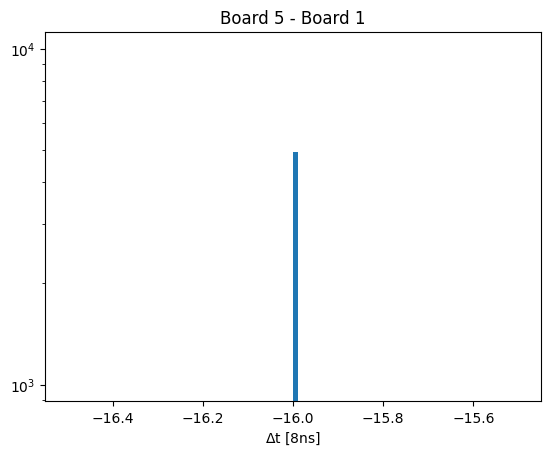

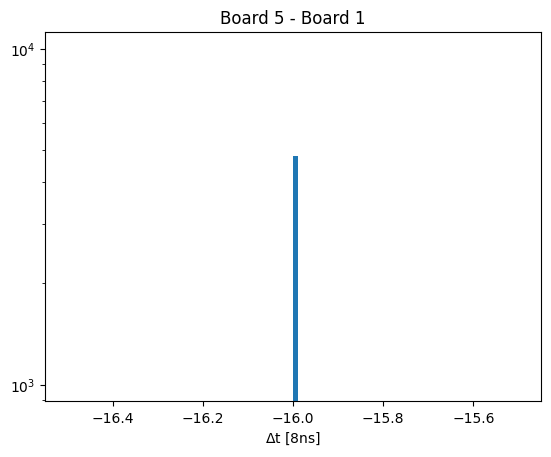

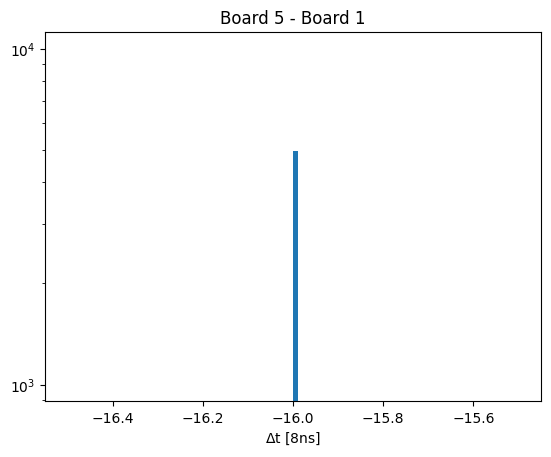

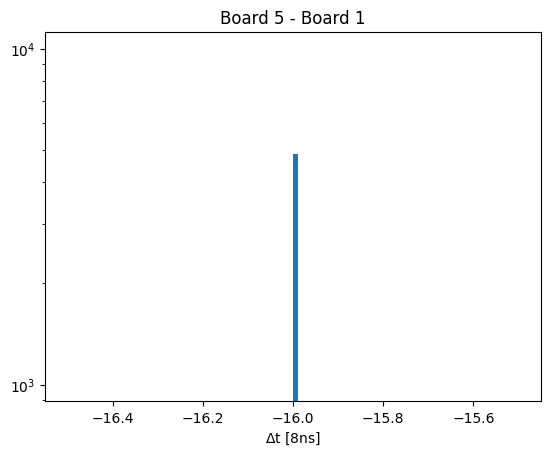

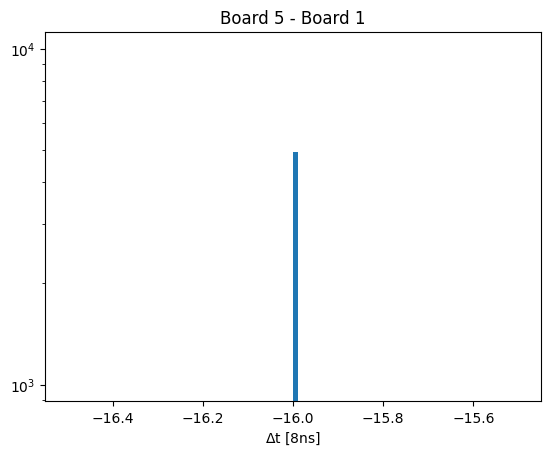

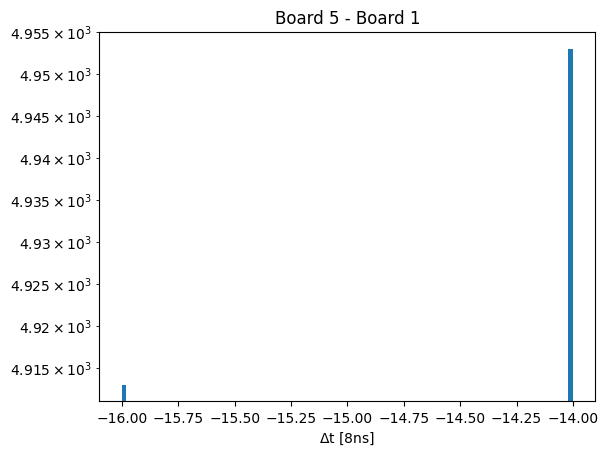

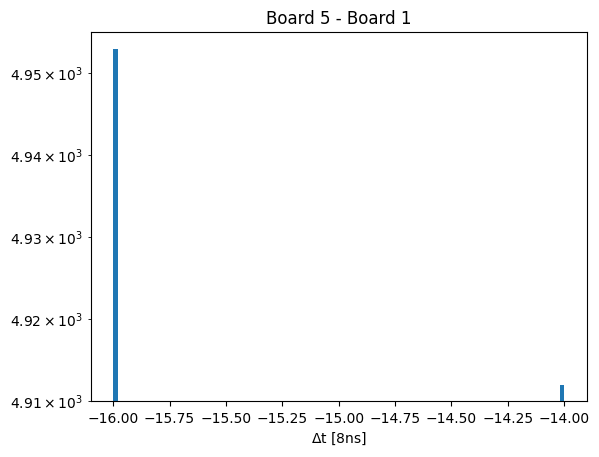

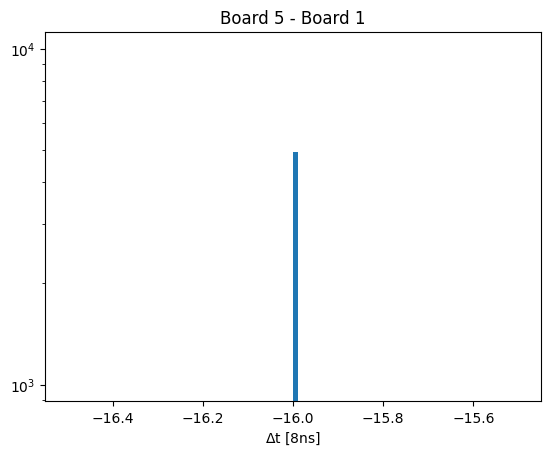

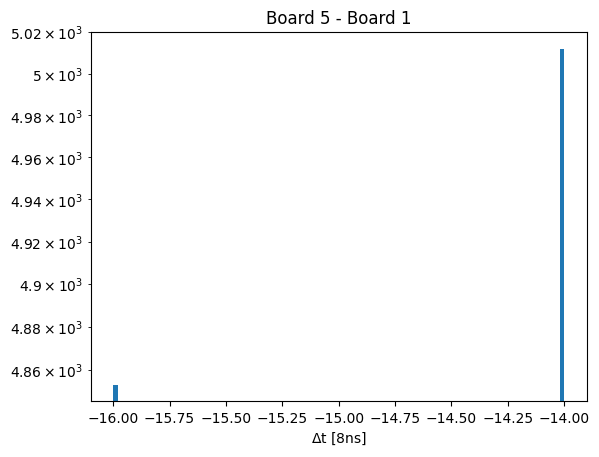

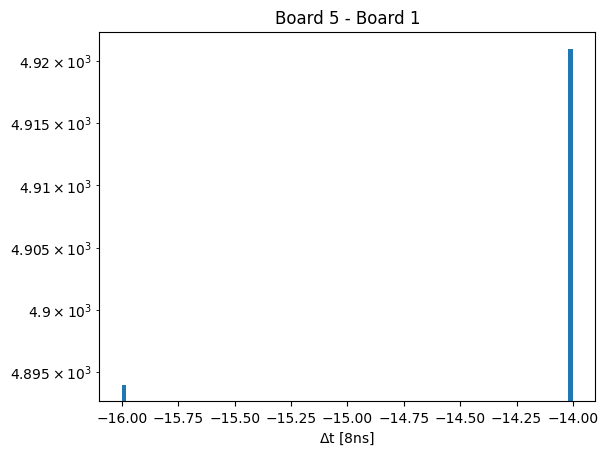

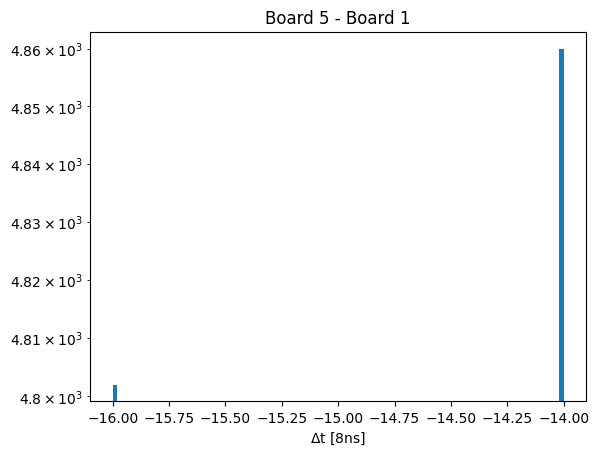

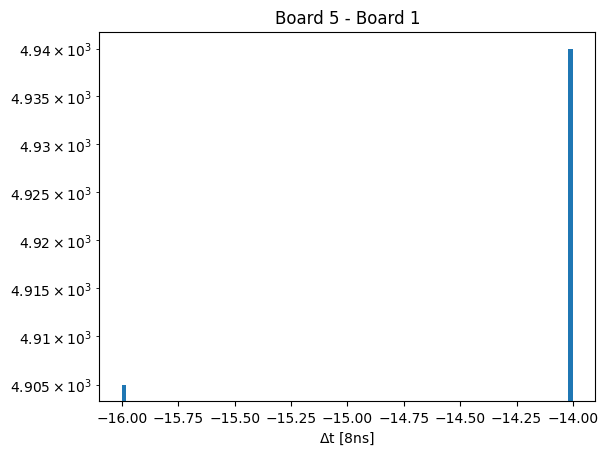

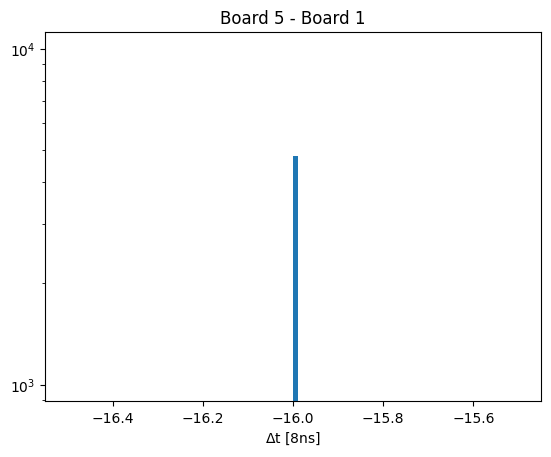

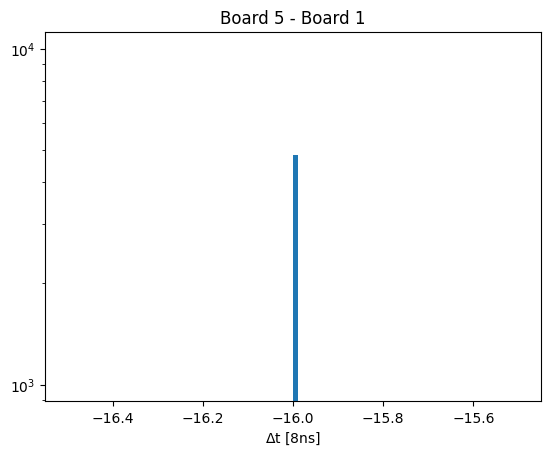

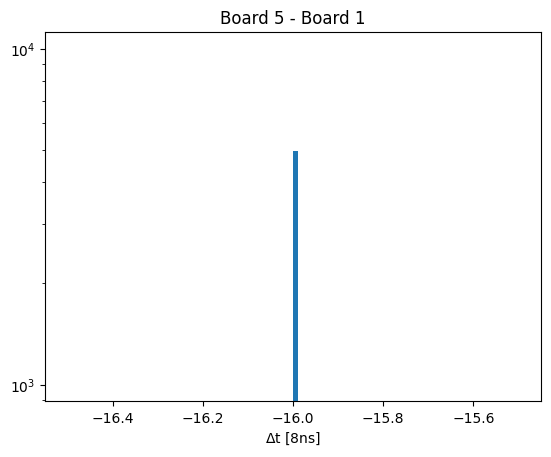

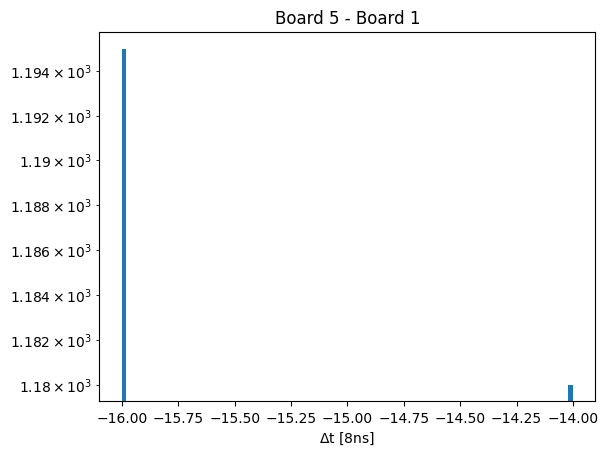

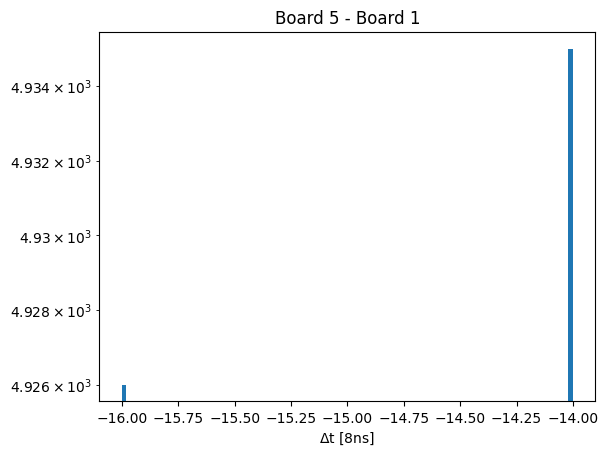

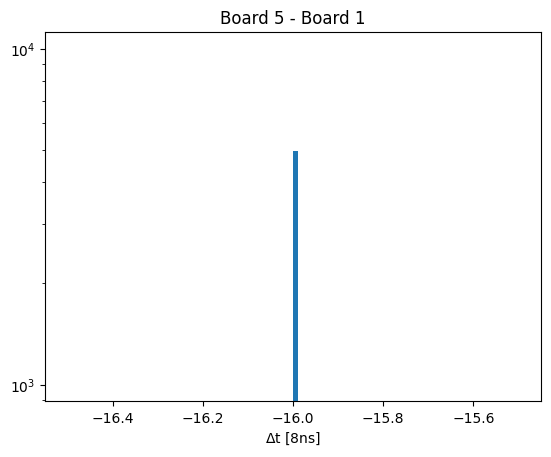

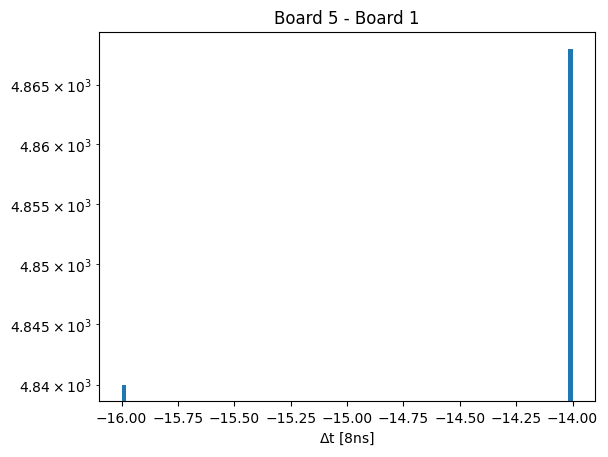

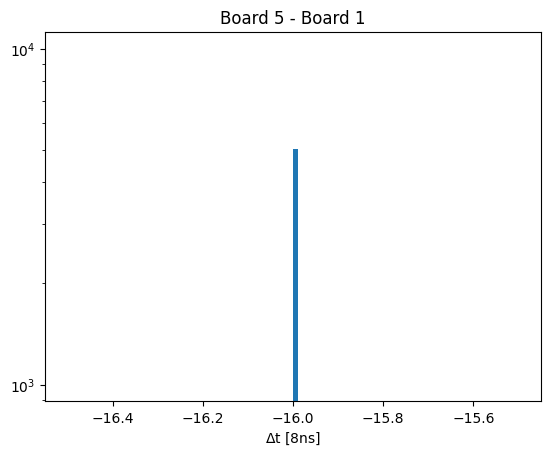

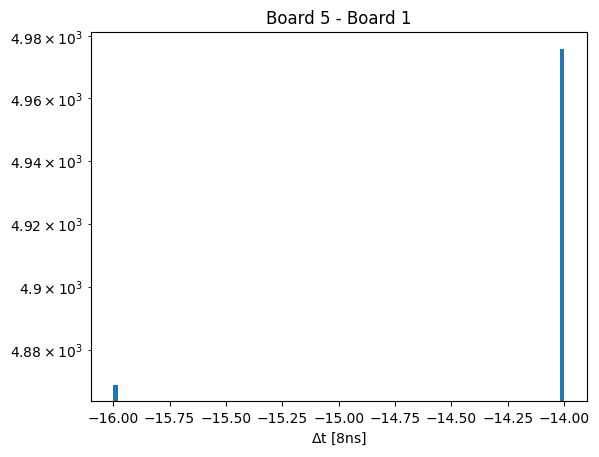

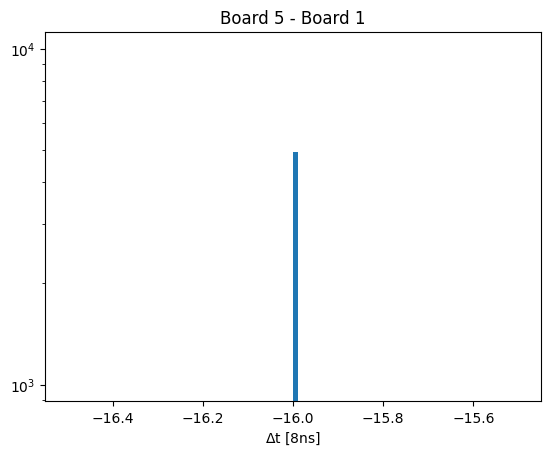

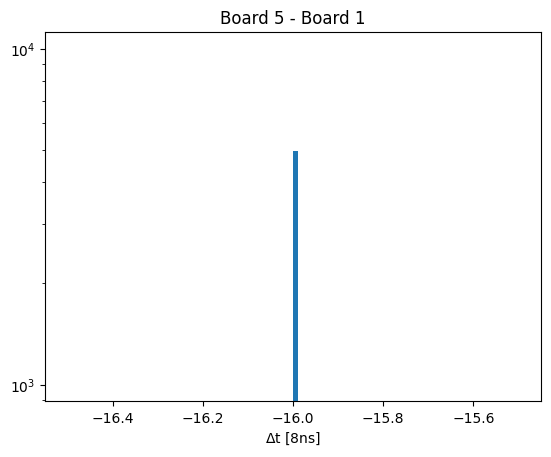

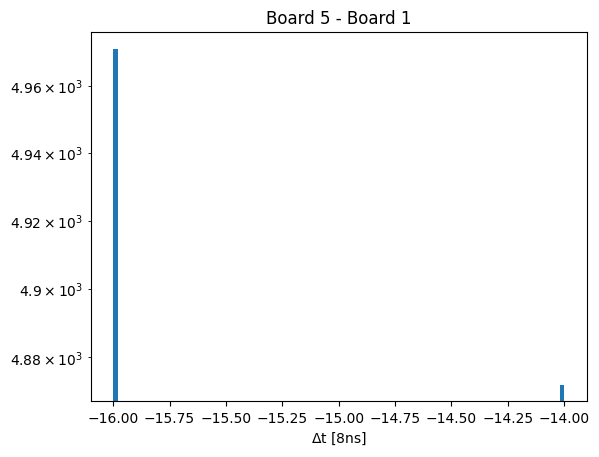

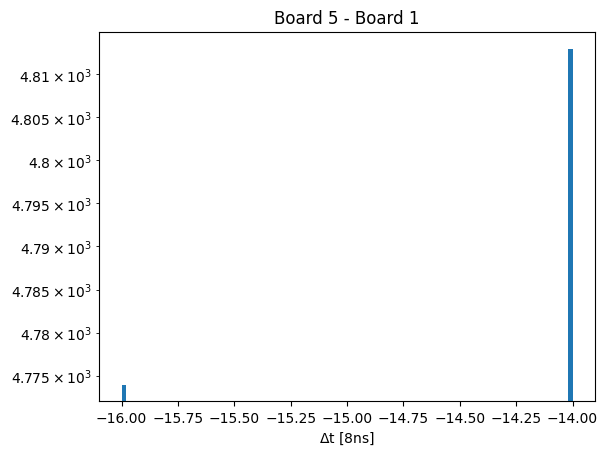

In [ ]:
phase_directory = "/media/disk_o/my_corrected_roots/disk_d_phase3/"  # corrected
file_paths_in_phase = [
    phase_directory + str(f)
    for f in os.listdir(phase_directory)
    if os.path.isfile(os.path.join(phase_directory, f))
]
for f in file_paths_in_phase:
    traces, event_ttt1, event_ttt2, event_ttt3, event_ttt4, event_ttt5, event_id, event_sanity = get_1t_traces(f)
    diff51 = event_ttt5 - event_ttt1

    plt.hist(diff51, bins=100)
    plt.yscale('log')
    plt.title('Board 5 - Board 1')
    plt.xlabel(r'$\Delta$t [8ns]')
    plt.show()
    plt.close()